# 01 - LV Scar Exploration

Focus: Core Zone (CZ) only.

Pipeline:
1. Scan + EDA
2. 80/20 split
3. 3-D visualisation (aligned overlay + grid)
4. 2-D polar maps + superposition
5. ISOMAP shape analysis

## 0 - Imports & config

In [4]:
import json, random, sys
from dataclasses import dataclass, field
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv
from scipy.spatial.distance import cdist
from sklearn.manifold import Isomap
from tqdm import tqdm

def _find_project_root():
    for base in [Path.cwd(), *Path.cwd().parents]:
        for candidate in (base, base / "lv-scar-segmentation"):
            if (candidate / "src" / "data_loading.py").exists():
                return candidate.resolve()
    raise FileNotFoundError(
        "Could not locate the lv-scar-segmentation project root from the current working directory."
    )

ROOT = _find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.data_loading import scan, diagnose, PatientCase
import pandas as pd

HD_ROOT          = r"F:/RM_TEKNON_DEVELOP"
SEED             = 42
TRAIN_RATIO      = 0.80
N_R              = 64
N_THETA          = 128
GRID3D_MAX       = 24
ISOMAP_PTS       = 800
ISOMAP_K         = 10
MIN_VERTS_FRAGMENT = 30
MIN_VERTS_ISOMAP = 5
MAX_PLOT_FRAGMENTS = 4

                        # False: only real CZ cases

RESULTS = ROOT / "results"
RESULTS.mkdir(exist_ok=True)
OUT = RESULTS / "01_scar_exploration"
OUT.mkdir(parents=True, exist_ok=True)

pv.set_jupyter_backend("static")
plt.rcParams["figure.dpi"] = 120
CLINICAL_CSV          = "C:/Users/joan/Desktop/FEINA/UPF/TFG/develop-vt.csv"  # path to clinical registry CSV
FLIP_SEPTAL_DIRECTION = False  # set True if RV appears on the LEFT (flips septal rotation)


## 1 - Scan & EDA

Scan external HD for all patient cases. Each case resolves LV shell (endo/epi/myocardium) and tissue surfaces (Core Zone, Border Zone, Scar). EDA checks case counts and missing anatomy.


In [5]:
# ── 1  Scan & EDA ──────────────────────────────────────────────────────────────
all_cases = scan(HD_ROOT)

def has_lv(c):
    return c.lv_dir is not None

def has_cz(c):
    p = c.tissue_surfaces.get("core")
    return p is not None and p.exists()

valid = [c for c in all_cases if has_cz(c)]

_DE_MRI_VARIANTS = ("DE-MRI", "DE-MRI 3D", "DE-MRI 2D")

def _diagnose_case(c):
    base = Path(c.root) / "Basal" / "Data"
    if not base.exists():
        return "no Basal/Data path"
    variants_found = [v for v in _DE_MRI_VARIANTS if (base / v).exists()]
    if not variants_found:
        return f"no DE-MRI folder (tried: {', '.join(_DE_MRI_VARIANTS)})"
    if c.lv_dir is None:
        return f"DE-MRI found ({variants_found[0]}) but no LV subfolder"
    tissue = c.lv_dir / "TISSUE"
    if not tissue.exists():
        return "no TISSUE folder"
    vtks = list(tissue.rglob("*.vtk"))
    if not vtks:
        return "TISSUE exists but no VTK files"
    core = c.tissue_surfaces.get("core")
    if core is None:
        return f"no CZ match in TISSUE (files: {[f.name for f in vtks[:8]]})"
    if core.stat().st_size == 0:
        return "CZ file is empty (0 bytes)"
    return "ok"

_SEP = "─" * 48

# ── Dataset overview (print + CSV) ───────────────────────────────────────────────
print(f"{'DATASET OVERVIEW':^48}")
print(_SEP)
print(f"  {'Year':<6}  {'Total':>7}  {'Has LV':>8}  {'Has CZ':>8}")
print(_SEP)

_overview_rows = []
for year in sorted(set(c.year for c in all_cases)):
    yc    = [c for c in all_cases if c.year == year]
    n_lv_ = sum(1 for c in yc if has_lv(c))
    n_cz_ = sum(1 for c in yc if has_cz(c))
    print(f"  {year:<6}  {len(yc):>7}  {n_lv_:>8}  {n_cz_:>8}")
    _overview_rows.append({"year": year, "total": len(yc), "has_lv": n_lv_, "has_cz": n_cz_})

print(_SEP)
n_tot = len(all_cases)
n_lv  = sum(1 for c in all_cases if has_lv(c))
n_cz  = sum(1 for c in all_cases if has_cz(c))
print(f"  {'TOTAL':<6}  {n_tot:>7}  {n_lv:>8}  {n_cz:>8}")
print(_SEP)
print(f"-> {n_cz} valid cases (with CZ) proceed to analysis.")
_overview_rows.append({"year": "TOTAL", "total": n_tot, "has_lv": n_lv, "has_cz": n_cz})

import csv as _csv_mod
_ov_path = OUT / "eda_dataset_overview.csv"
with open(_ov_path, "w", newline="", encoding="utf-8") as _f:
    _w = _csv_mod.DictWriter(_f, fieldnames=["year","total","has_lv","has_cz"])
    _w.writeheader(); _w.writerows(_overview_rows)
print(f"Saved: {_ov_path}")

# ── Missing cases (print + CSV) ─────────────────────────────────────────────────
_missing_rows = []

def _print_missing(cases, label, status):
    print(f"{label}: {len(cases)}")
    if not cases:
        return
    diagnosed = [(c, _diagnose_case(c)) for c in cases]
    counts = Counter(d for _, d in diagnosed)
    for reason, cnt in counts.most_common():
        ids = [str(c.patient_id) for c, d in diagnosed if d == reason]
        print(f"  {cnt:>3}x  {reason}")
        print(f"        IDs: {', '.join(ids)}")
        for pid in ids:
            _missing_rows.append({"patient_id": pid, "status": status, "reason": reason})

_print_missing([c for c in all_cases if not has_lv(c)], "Without LV dir", "no_lv")
print()
_print_missing([c for c in all_cases if has_lv(c) and not has_cz(c)], "With LV but no CZ", "no_cz")

_miss_path = OUT / "eda_missing_cases.csv"
with open(_miss_path, "w", newline="", encoding="utf-8") as _f:
    _w = _csv_mod.DictWriter(_f, fieldnames=["patient_id","status","reason"])
    _w.writeheader(); _w.writerows(_missing_rows)
print(f"Saved: {_miss_path}  ({len(_missing_rows)} missing cases)")


                DATASET OVERVIEW                
────────────────────────────────────────────────
  Year      Total    Has LV    Has CZ
────────────────────────────────────────────────
  2021         48        12        12
  2022         27        23        23
  2023         47        45        32
  2024         31        31        31
  2025         15         7         7
────────────────────────────────────────────────
  TOTAL       168       118       105
────────────────────────────────────────────────
-> 105 valid cases (with CZ) proceed to analysis.
Saved: C:\Users\joan\Desktop\FEINA\UPF\TFG\repo\scar-char-v0.1\lv-scar-segmentation\results\01_scar_exploration\eda_dataset_overview.csv
Without LV dir: 50
   35x  no DE-MRI folder (tried: DE-MRI, DE-MRI 3D, DE-MRI 2D)
        IDs: 00021123, 01041694, 02002319, 02011130, 02020684, 03015023, 03031339, 04020449, 05001858, 05027445, 05044223, 06040109, 06050540, 07037693, 07043391, 07044737, 08022556, 18022861, 18042739, 98027481, 9803767

## 2 - 80/20 split

Random seeded split of valid cases (those with a CZ mesh) into **Known (~80%)** and **Held-out (~20%)**. Known set is used for all EDA and analysis. Split serialised to  for reproducibility.


In [6]:
random.seed(SEED)
shuffled = random.sample(valid, len(valid))
n_known  = int(len(shuffled) * TRAIN_RATIO)
known    = shuffled[:n_known]
held_out = shuffled[n_known:]

(RESULTS / "split.json").write_text(json.dumps({
    "seed": SEED, "train_ratio": TRAIN_RATIO,
    "known":    [f"{c.year}/{c.patient_id}" for c in known],
    "held_out": [f"{c.year}/{c.patient_id}" for c in held_out],
}, indent=2))
print(f"Known: {len(known)}   Held-out: {len(held_out)}")


Known: 84   Held-out: 21


In [7]:
# ── Load clinical sex for stratified plots ────────────────────────────────────
# clinical_data.py maps SEXO -> sex  (1 = male, 2 = female)
sex_map = {}  # patient_id (str) -> 'M' or 'F'

_csv = CLINICAL_CSV
if _csv is not None:
    try:
        from src.clinical_data import load as _load_clinical
        _cdf = _load_clinical(_csv)
        # after clinical_data.load(): col = "sex" (int: 1=M, 2=F), id col = "patient_id"
        if "sex" in _cdf.columns and "patient_id" in _cdf.columns:
            _sex_raw = {str(row["patient_id"]): int(row["sex"])
                        for _, row in _cdf[["patient_id","sex"]].dropna().iterrows()}
            sex_map  = {pid: ("M" if v == 1 else "F") for pid, v in _sex_raw.items()}
            print(f"Sex loaded: {len(sex_map)} patients  {dict(Counter(sex_map.values()))}")
        else:
            print(f"Expected cols 'patient_id' and 'sex', got: {list(_cdf.columns[:20])}")
    except Exception as _e:
        print(f"Clinical CSV failed: {_e}")
else:
    print("CLINICAL_CSV = None — sex stratification skipped.")


Sex loaded: 94 patients  {'M': 79, 'F': 15}


## 3 - 3-D visualisation

Off-screen PyVista render per case: semi-transparent LV shell + opaque Core Zone (red). Used for visual QC of segmentation quality and scar morphology.


In [8]:
from src.mesh_utils import best_shell as _best_shell, get_cz_mesh
from src.lv_geometry import (
    apply_transform as _apply_transform,
    compute_transform as _compute_transform_base,
    oriented_septal_reference as _base_oriented_septal_reference,
    plane_basis as _plane_basis,
    rotation_about_z as _rotation_about_z,
    rv_reference_pca as _rv_reference_pca,
)


def _oriented_septal_reference(ref):
    return _base_oriented_septal_reference(
        ref,
        flip=globals().get("FLIP_SEPTAL_DIRECTION", False),
    )


def _compute_transform(lv_mesh, align_septum=False):
    return _compute_transform_base(
        lv_mesh,
        align_septum=align_septum,
        flip_septal_direction=globals().get("FLIP_SEPTAL_DIRECTION", False),
    )

print("3-D helpers ready (shared src.mesh_utils/src.lv_geometry).")


3-D helpers ready (shared src.mesh_utils/src.lv_geometry).


### 3b - Per-patient 3-D grid (first GRID3D_MAX cases)

3-D grid: 100%|██████████| 84/84 [00:33<00:00,  2.49it/s]


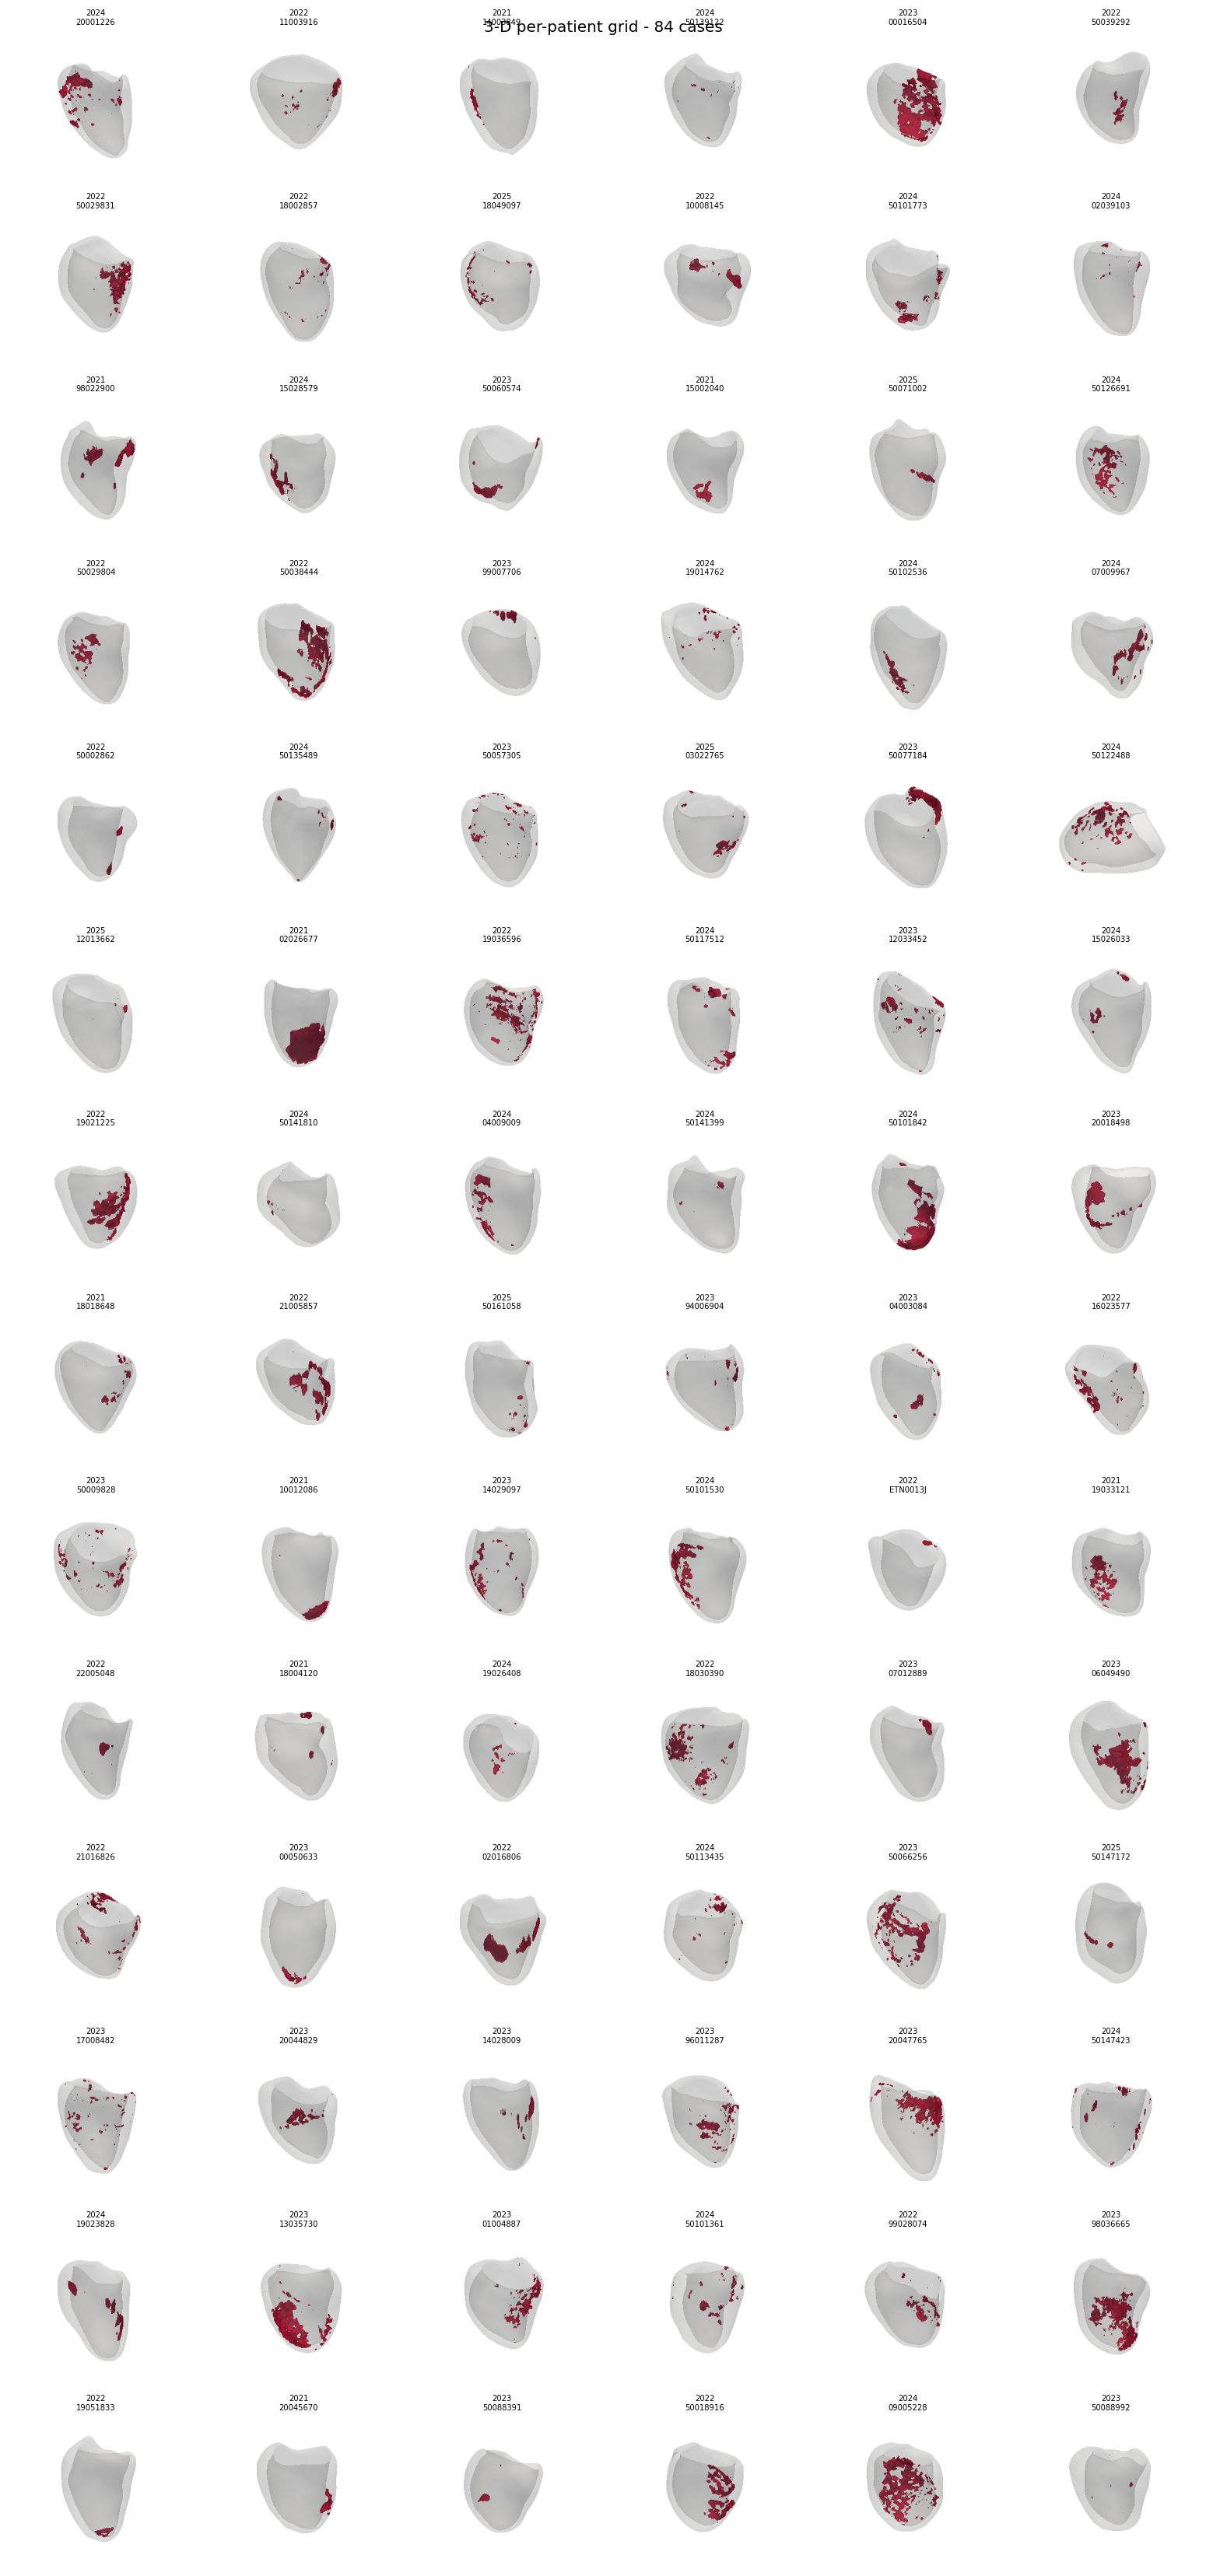

In [9]:
subset   = known
ncols_3d = 6
nrows_3d = int(np.ceil(len(subset) / ncols_3d))

thumbnails = []
for case in tqdm(subset, desc='3-D grid'):
    try:
        cz = get_cz_mesh(case)
        if cz is None:
            continue
        pl = pv.Plotter(off_screen=True, window_size=(300, 260))
        pl.set_background('white')
        shell = _best_shell(case)
        if shell is not None:
            pl.add_mesh(shell, color='#cccccc', opacity=0.15,
                        smooth_shading=True, show_scalar_bar=False)
        pl.add_mesh(cz, color='crimson', opacity=0.95,
                    smooth_shading=True, show_scalar_bar=False)
        pl.view_isometric()
        thumbnails.append((case, pl.screenshot(None, return_img=True)))
        pl.close()
    except Exception as e:
        print(f'  skip {case.year}/{case.patient_id}: {e}')

fig, axes = plt.subplots(nrows_3d, ncols_3d,
                         figsize=(ncols_3d * 2.2, nrows_3d * 2),
                         squeeze=False)
fig.suptitle(f'3-D per-patient grid - {len(thumbnails)} cases',
             fontsize=12)
axes_flat = axes.ravel()
for ax in axes_flat:
    ax.axis('off')
for ax, (case, img) in zip(axes_flat, thumbnails):
    ax.imshow(img)
    ax.set_title(f'{case.year}\n{case.patient_id}', fontsize=6)
plt.tight_layout()
plt.savefig(OUT / '3d_grid_known.png', bbox_inches='tight')
plt.show()

In [ ]:
### 3c - Per-patient 3-D grid (rotated 120°)

thumbnails_rot = []
for case in tqdm(subset, desc="3-D grid 120deg"):
    try:
        cz = get_cz_mesh(case)
        if cz is None:
            continue
        pl = pv.Plotter(off_screen=True, window_size=(300, 260))
        pl.set_background("white")
        shell = _best_shell(case)
        if shell is not None:
            pl.add_mesh(shell, color="#cccccc", opacity=0.15,
                        smooth_shading=True, show_scalar_bar=False)
        pl.add_mesh(cz, color="crimson", opacity=0.95,
                    smooth_shading=True, show_scalar_bar=False)
        pl.view_isometric()
        pl.camera.azimuth += 120
        thumbnails_rot.append((case, pl.screenshot(None, return_img=True)))
        pl.close()
    except Exception as e:
        print(f"  skip {case.year}/{case.patient_id}: {e}")

fig, axes = plt.subplots(nrows_3d, ncols_3d,
                         figsize=(ncols_3d * 2.2, nrows_3d * 2),
                         squeeze=False)
fig.suptitle(f"3-D per-patient grid (rotated 120°) — {len(thumbnails_rot)} cases",
             fontsize=12)
axes_flat = axes.ravel()
for ax in axes_flat:
    ax.axis("off")
for ax, (case, img) in zip(axes_flat, thumbnails_rot):
    ax.imshow(img)
    ax.set_title(f"{case.year}{case.patient_id}", fontsize=6)
plt.tight_layout()
plt.savefig(OUT / "3d_grid_known_rot120.png", bbox_inches="tight")
plt.show()


3-D grid 120deg:  45%|████▌     | 38/84 [00:23<00:49,  1.07s/it]

### 3d - Anatomically aligned 3-D grid

This grid applies `_compute_transform(..., align_septum=True)` before rendering: apex is the origin, apex-to-base is `+Z`, and the PCA septal/RV reference is rotated to `+X`. The side-view camera keeps `+Z` vertical and `+X` on screen-right. For apex-to-base thumbnails, the already aligned LV is then rolled in-plane so the septal/RV reference appears in the upper-left AHA sector.

3-D grid anatomical side: 100%|██████████| 84/84 [02:17<00:00,  1.63s/it]


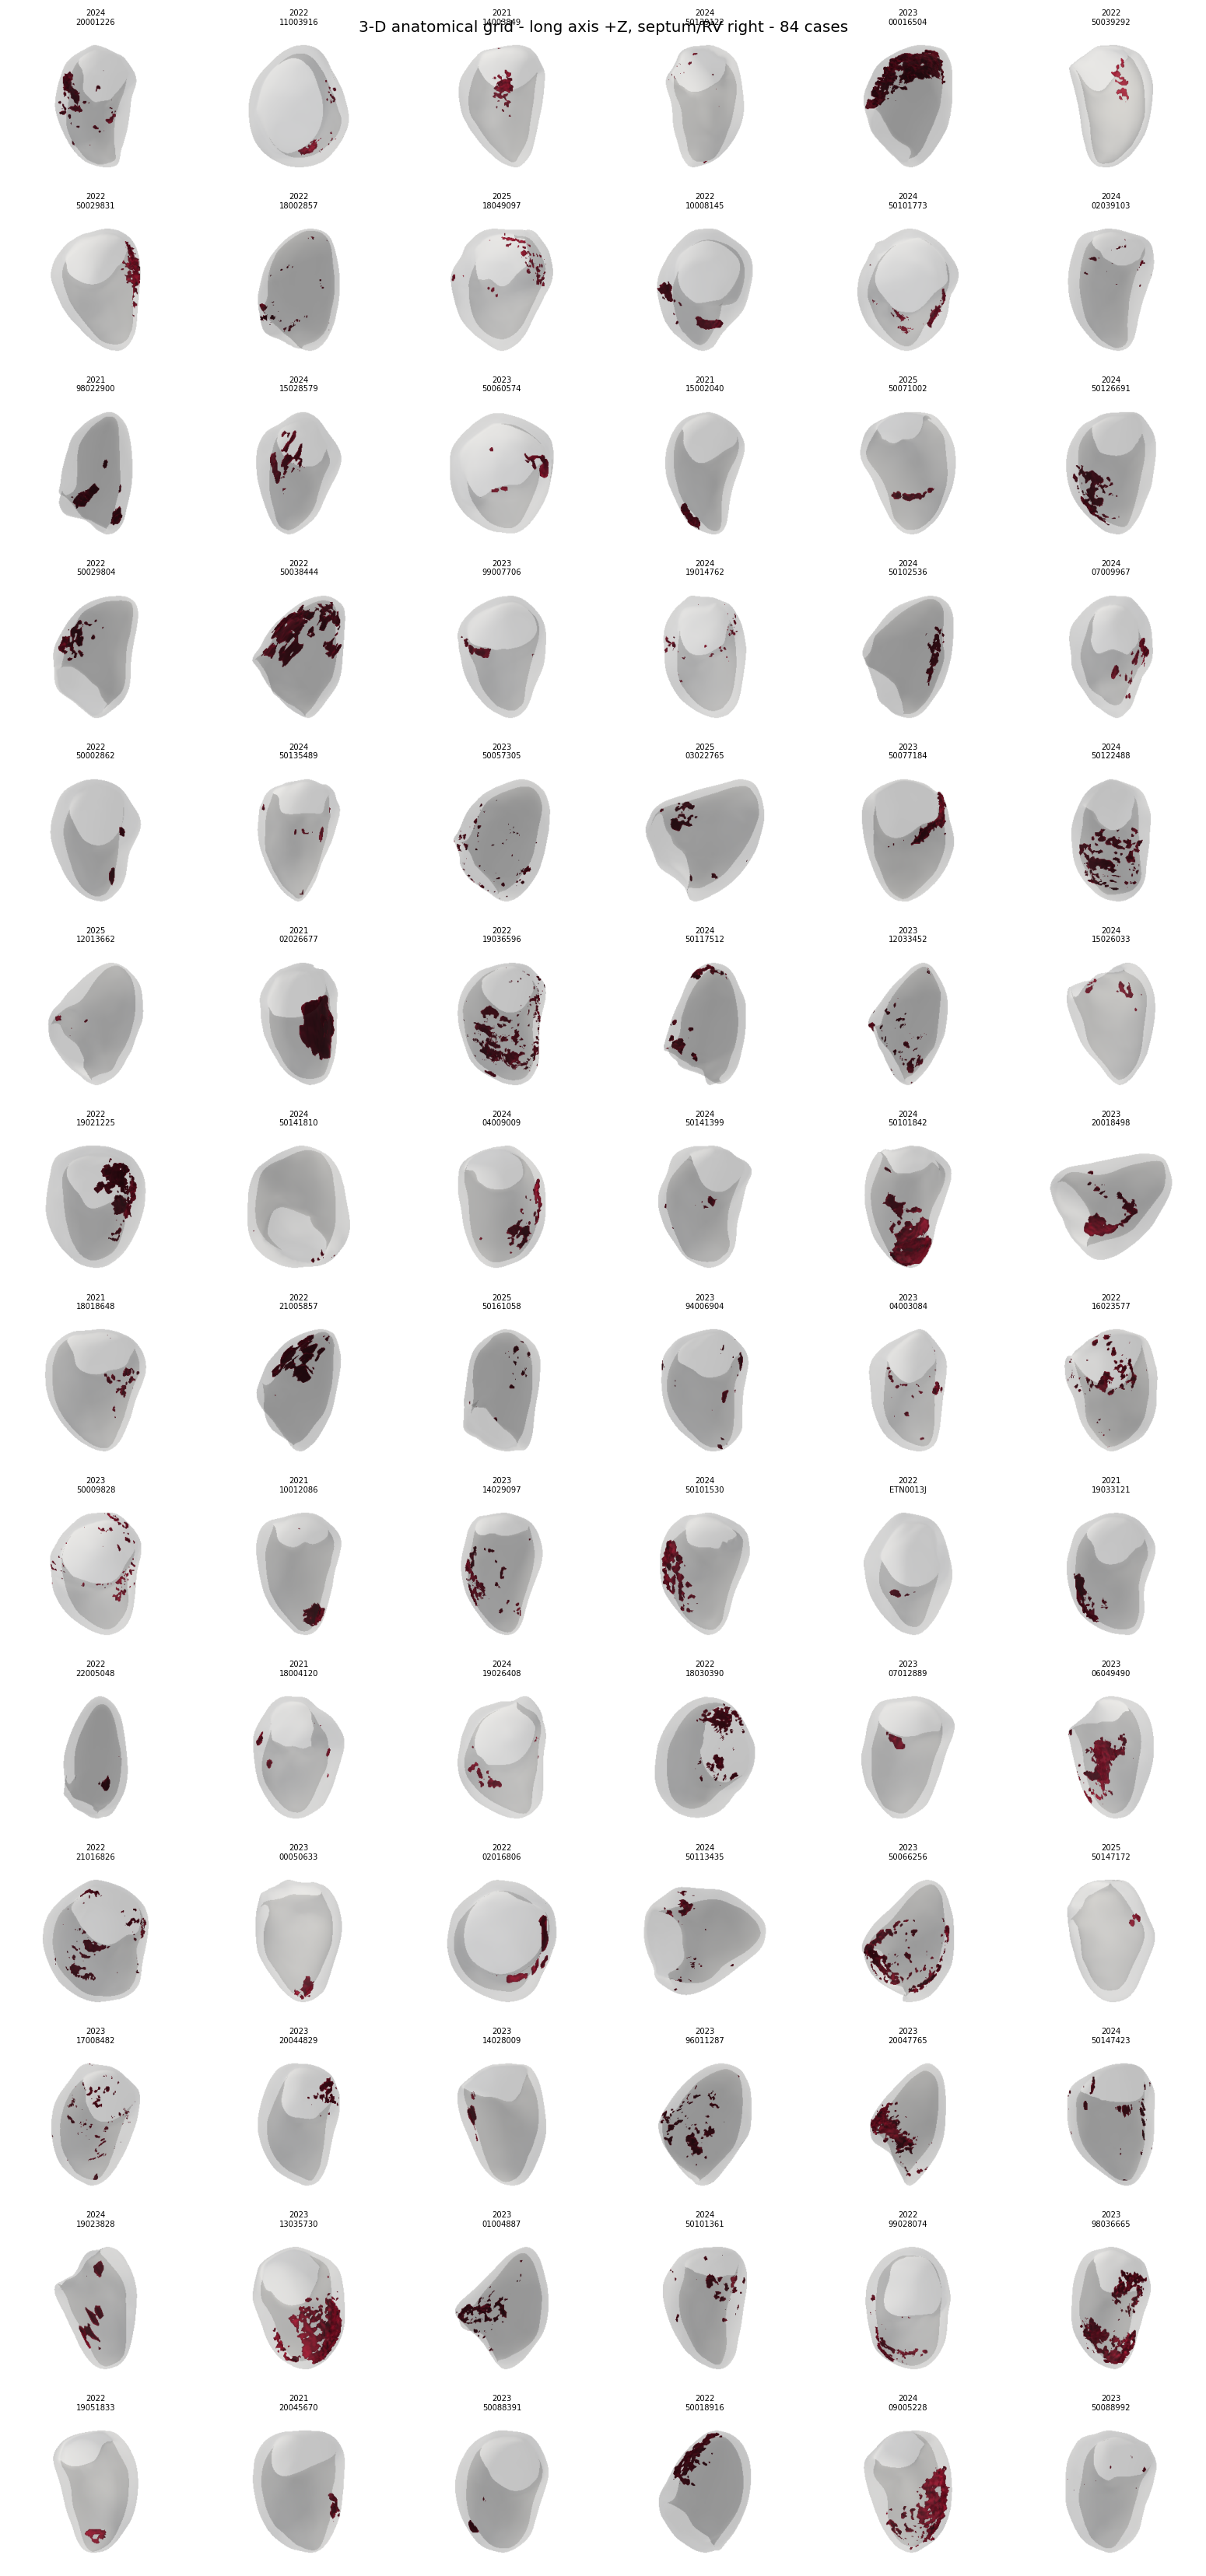

In [ ]:
_AHA_APEX_TO_BASE_SEPTAL_DEG = 45.0  # top/apical display: septum in the 9-12 o'clock sector


def _display_rotation_for_view(view):
    if view == "apex_to_base":
        return _AHA_APEX_TO_BASE_SEPTAL_DEG
    return 0.0


def _set_anatomic_camera(pl, view, fixed_span=None):
    bounds = np.array(pl.bounds, dtype=float)
    center = np.array([
        0.5 * (bounds[0] + bounds[1]),
        0.5 * (bounds[2] + bounds[3]),
        0.5 * (bounds[4] + bounds[5]),
    ])
    span = fixed_span if fixed_span is not None else max(bounds[1] - bounds[0], bounds[3] - bounds[2], bounds[5] - bounds[4], 1.0)
    dist = 2.8 * span
    if view == "septal_right":
        offset = np.array([0., -dist, 0.])
        viewup = (0., 0., 1.)
    elif view == "apex_to_base":
        offset = np.array([0., 0., -dist])
        viewup = (0., 1., 0.)
    else:
        raise ValueError(f"unknown anatomic view: {view}")
    pl.camera_position = [tuple(center + offset), tuple(center), viewup]
    pl.enable_parallel_projection()
    pl.camera.zoom(1.18)


def _render_anatomic_case(case, view, window_size=(300, 260), display_rotation_deg=None, fixed_span=None):
    shell = _best_shell(case)
    cz = get_cz_mesh(case)
    if shell is None or cz is None:
        return None
    R, apex = _compute_transform(shell, align_septum=True)
    if display_rotation_deg is None:
        display_rotation_deg = _display_rotation_for_view(view)
    if abs(display_rotation_deg) > 1e-9:
        R = _rotation_about_z(np.deg2rad(display_rotation_deg)) @ R
    shell_a = _apply_transform(shell, R, apex)
    cz_a = _apply_transform(cz, R, apex)

    pl = pv.Plotter(off_screen=True, window_size=window_size)
    try:
        pl.set_background("white")
        pl.add_mesh(shell_a, color="#cccccc", opacity=0.15,
                    smooth_shading=True, show_scalar_bar=False)
        pl.add_mesh(cz_a, color="crimson", opacity=0.95,
                    smooth_shading=True, show_scalar_bar=False)
        _set_anatomic_camera(pl, view, fixed_span=fixed_span)
        return pl.screenshot(None, return_img=True)
    finally:
        pl.close()


def _plot_3d_thumbnail_grid(thumbnails, title, filename):
    fig, axes = plt.subplots(nrows_3d, ncols_3d,
                             figsize=(ncols_3d * 2.2, nrows_3d * 2),
                             squeeze=False)
    fig.suptitle(title, fontsize=12)
    axes_flat = axes.ravel()
    for ax in axes_flat:
        ax.axis("off")
    for ax, (case, img) in zip(axes_flat, thumbnails):
        ax.imshow(img)
        ax.set_title(f"{case.year}\n{case.patient_id}", fontsize=6)
    plt.tight_layout()
    plt.savefig(OUT / filename, bbox_inches="tight")
    plt.show()


thumbnails_anat = []
for case in tqdm(subset, desc="3-D grid anatomical side"):
    try:
        img = _render_anatomic_case(case, view="septal_right")
        if img is not None:
            thumbnails_anat.append((case, img))
    except Exception as e:
        print(f"  skip {case.year}/{case.patient_id}: {e}")

_plot_3d_thumbnail_grid(
    thumbnails_anat,
    f"3-D anatomical grid - long axis +Z, septum/RV right - {len(thumbnails_anat)} cases",
    "3d_grid_known_anatomic_septal_right.png",
)


### 3e - Anatomically aligned top grid

Top-down view of the same aligned meshes, looking from apex toward base. This matches the polar-map viewing convention: the septal reference is first controlled on the right side of the LV frame, then the apex-to-base camera puts the septal sector into the 9-12 o'clock region of the bull's-eye.

In [ ]:
# Pass 1: compute shared LV span across all cases in the aligned frame
_spans_top = []
_span_skips_top = 0
for _case in subset:
    try:
        _shell = _best_shell(_case)
        if _shell is None:
            continue
        _R, _apex = _compute_transform(_shell, align_septum=True)
        _R = _rotation_about_z(np.deg2rad(_AHA_APEX_TO_BASE_SEPTAL_DEG)) @ _R
        _shell_a = _apply_transform(_shell, _R, _apex)
        _b = np.array(_shell_a.bounds, dtype=float)
        _spans_top.append(max(_b[1] - _b[0], _b[3] - _b[2], _b[5] - _b[4]))
    except Exception as _e:
        _span_skips_top += 1
_global_span_top = float(np.median(_spans_top)) if _spans_top else None
if _global_span_top is None:
    print("Global LV span (apex-to-base grid): unavailable (n=0 cases); using per-case camera span.")
else:
    print(f"Global LV span (apex-to-base grid): {_global_span_top:.1f} mm  (n={len(_spans_top)} cases)")
if _span_skips_top:
    print(f"Skipped {_span_skips_top} cases while computing shared span.")

# Pass 2: render all cases with the shared camera span
thumbnails_top = []
for case in tqdm(subset, desc="3-D grid apex-to-base"):
    try:
        img = _render_anatomic_case(case, view="apex_to_base", fixed_span=_global_span_top)
        if img is not None:
            thumbnails_top.append((case, img))
    except Exception as e:
        print(f"  skip {case.year}/{case.patient_id}: {e}")

_plot_3d_thumbnail_grid(
    thumbnails_top,
    f"3-D anatomical grid - apex-to-base; septum upper-left - {len(thumbnails_top)} cases",
    "3d_grid_known_anatomic_top.png",
)


## 4 - 2-D cylindrical polar projection

Each patient's CZ mesh is projected onto a shared **64 x 128** bull's-eye grid (rows = longitudinal, cols = circumferential) so grids from different patients can be averaged into a population scar density map.

### Algorithm — 7 stages

| Stage | Operation | Why |
|---|---|---|
| 1 | Load LV shell + CZ mesh | Shell = geometry reference; CZ = scar to project |
| 2 | SVD on LV shell -> long axis + apex | LV is tall/narrow: PC1 captures apex->base direction |
| 3 | Build cross-section frame (u, w perp to axis) | Defines 2-D plane for circumferential angles |
| 4 | PCA on basal ring (60-85%) -> septal ref direction | Ring is kidney-shaped (RV insertion); PC1 passes through both RV attachment concavities; half with smaller mean radius = septum |
| 5 | Project each CZ vertex: s = along-axis [0=apex, 1=base]; theta = angle from septal ref | Removes patient-specific position and rotational offset |
| 6 | Bin (s, theta) -> 64x128 bool grid | ri = s*64, ti = theta/(2pi)*128 |
| 7 | Stack N grids -> mean = density map | Each cell = fraction of patients with scar there |

### Why this projection is good

- **Patient-independent coordinates**: every (ri, ti) cell has the same anatomical meaning across all patients — apex at centre, base at outer ring, septum at a fixed angle.
- **Valid population superposition**: averaging N binary grids yields a scar probability map because all patients share the same coordinate system.
- **AHA-17 overlay**: the 17-segment model divides the bull's eye into clinically reportable zones.

### Display convention (AHA standard — apical view)

```
        ANT  (12 o'clock)
         |
 SEPT ---+----  LAT
(9-12)   |          (3 o'clock)
         |
        INF  (6 o'clock)
```

- **Septal / RV insertion reference** = **upper-left, between 9 and 12 o'clock**
- AHA septal segments: **2 & 8** (anteroseptal, upper-left), **3 & 9** (inferoseptal, lower-left), **14** (apical septal)


In [ ]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d
from scipy.signal import find_peaks
import matplotlib.gridspec as gridspec

if "ROOT" not in globals():
    def _find_project_root():
        for base in [Path.cwd(), *Path.cwd().parents]:
            for candidate in (base, base / "lv-scar-segmentation"):
                if (candidate / "src" / "data_loading.py").exists():
                    return candidate.resolve()
        raise FileNotFoundError(
            "Could not locate the lv-scar-segmentation project root from the current working directory."
        )
    ROOT = _find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

N_R = globals().get("N_R", 64)
N_THETA = globals().get("N_THETA", 128)
from src.mesh_utils import best_shell as _best_shell, get_cz_mesh
from src.lv_geometry import (
    long_axis as _long_axis,
    oriented_septal_reference as _base_oriented_septal_reference,
    plane_basis as _plane_basis,
    rv_reference_pca as _rv_reference_pca,
)

def _rv_reference(lv_mesh, axis, apex, z_lo=0.60, z_hi=0.85):
    """Method A - dip detection: direction toward midpoint of 2 deepest radial dips.

    The two deepest concavities in the basal ring correspond to the RV attachment
    points. Falls back to an arbitrary stable direction when fewer than 2 dips
    are found. Sensitive to manual segmentation artefacts that introduce extra dips.
    """
    u, w  = _plane_basis(axis)
    pts   = np.array(lv_mesh.points)
    proj  = (pts - apex) @ axis
    span  = proj.max() - proj.min()
    mask  = (proj >= z_lo * span) & (proj <= z_hi * span)
    ring  = pts[mask]
    if len(ring) < 20:
        return u
    ring_2d  = np.column_stack([(ring - apex) @ u, (ring - apex) @ w])
    centroid = ring_2d.mean(axis=0)
    diff     = ring_2d - centroid
    angles   = np.arctan2(diff[:, 1], diff[:, 0])
    radii    = np.linalg.norm(diff, axis=1)
    idx      = np.argsort(angles)
    smooth_r = uniform_filter1d(radii[idx], size=max(3, len(radii)//20), mode='wrap')
    peaks, _ = find_peaks(-smooth_r, distance=max(5, len(smooth_r)//8))
    if len(peaks) < 2:
        return u
    top2     = peaks[np.argsort(-smooth_r[peaks])[:2]]
    ins_ang  = np.arctan2(diff[idx[top2], 1], diff[idx[top2], 0])
    mid_2d   = np.array([np.cos(ins_ang).mean(), np.sin(ins_ang).mean()])
    norm     = np.linalg.norm(mid_2d)
    if norm < 1e-9:
        return u
    return (mid_2d[0] * u + mid_2d[1] * w) / norm


def _oriented_septal_reference(ref):
    return _base_oriented_septal_reference(
        ref,
        flip=globals().get("FLIP_SEPTAL_DIRECTION", False),
    )


_AHA_RING_RADII = (0.25, 0.50, 0.75)
_AHA_BASAL_MID_BOUNDS_DEG = (0, 60, 120, 180, 240, 300)
_AHA_APICAL_BOUNDS_DEG = (45, 135, 225, 315)
_AHA_SEPTAL_REFERENCE_DEG = 0.0    # W/CCW: theta=0 -> West -> 9-oclock = SEPT
_AHA_SEGMENT_LABELS = (
    # W/CCW: 0=West=9oclock(SEPT), 90=North=12oclock(ANT), 180=East=3oclock(LAT)
    (1,  90, 0.875), (2,  30, 0.875), (3, 330, 0.875),
    (4, 270, 0.875), (5, 210, 0.875), (6, 150, 0.875),
    (7,  90, 0.625), (8,  30, 0.625), (9, 330, 0.625),
    (10, 270, 0.625), (11, 210, 0.625), (12, 150, 0.625),
    (13,  90, 0.375), (14,   0, 0.375), (15, 270, 0.375), (16, 180, 0.375),
    (17,   0, 0.125),
)


def _theta_deg(deg):
    return np.deg2rad((deg + _AHA_SEPTAL_REFERENCE_DEG) % 360)


def _overlay_aha_segments(ax, label_segments=True, linecolor='#222222', linewidth=0.8):
    theta = np.linspace(0, 2*np.pi, 361)
    for radius in _AHA_RING_RADII:
        ax.plot(theta, np.full_like(theta, radius), color=linecolor, lw=linewidth, alpha=0.85)
    for deg in _AHA_BASAL_MID_BOUNDS_DEG:
        th = _theta_deg(deg)
        ax.plot([th, th], [_AHA_RING_RADII[1], 1.0], color=linecolor, lw=linewidth, alpha=0.85)
    for deg in _AHA_APICAL_BOUNDS_DEG:
        th = _theta_deg(deg)
        ax.plot([th, th], [0.0, _AHA_RING_RADII[1]], color=linecolor, lw=linewidth, alpha=0.85)
    if label_segments:
        for seg, deg, radius in _AHA_SEGMENT_LABELS:
            ax.text(_theta_deg(deg), radius, str(seg), fontsize=7, ha='center', va='center',
                    color='black', zorder=5,
                    bbox=dict(boxstyle='circle,pad=0.16', facecolor='white',
                              edgecolor='none', alpha=0.72))


DEFAULT_REF_FN = _rv_reference_pca
DEFAULT_REF_NAME = 'PCA'


def polar_map(case, n_r=N_R, n_theta=N_THETA, ref_fn=None):
    """Cylindrical polar projection of CZ onto a bull's-eye grid.

    ref_fn: callable(lv_mesh, axis, apex) -> unit 3-D direction.
            Defaults to _rv_reference_pca (Method B, PCA).
    """
    if ref_fn is None:
        ref_fn = DEFAULT_REF_FN
    shell = _best_shell(case)
    if shell is None:
        raise ValueError('no LV shell')
    axis, apex = _long_axis(shell)
    u, w       = _plane_basis(axis)
    ref        = ref_fn(shell, axis, apex)
    ref        = _oriented_septal_reference(ref)
    ref_angle  = np.arctan2(np.dot(ref, w), np.dot(ref, u))
    cz = get_cz_mesh(case)
    if cz is None:
        raise ValueError('no CZ mesh')
    lv_pts   = np.array(shell.points)
    lv_s_raw = (lv_pts - apex) @ axis
    s_min    = lv_s_raw.min()
    s_span   = lv_s_raw.max() - s_min + 1e-9

    pts   = np.array(cz.points)
    v     = pts - apex
    s_raw = v @ axis
    s     = np.clip((s_raw - s_min) / s_span, 0., 1.)
    perp  = v - np.outer(s_raw, axis)
    theta = (np.arctan2(perp @ w, perp @ u) - ref_angle) % (2 * np.pi)
    grid  = np.zeros((n_r, n_theta), dtype=bool)
    ri    = np.clip((s * n_r).astype(int), 0, n_r - 1)
    ti    = np.clip((theta / (2*np.pi) * n_theta).astype(int), 0, n_theta - 1)
    grid[ri, ti] = True
    return grid


def _draw_bullseye(grid, ax, title='', cmap='Reds', vmax=1.,
                   show_segments=True, label_segments=False):
    n_r, n_theta = grid.shape
    theta_offset = np.deg2rad(_AHA_SEPTAL_REFERENCE_DEG % 360)
    T, R = np.meshgrid(np.linspace(0, 2*np.pi, n_theta+1) + theta_offset,
                        np.linspace(0, 1, n_r+1))
    ax.pcolormesh(T, R, grid.astype(float), cmap=cmap,
                  vmin=0, vmax=vmax, shading='flat')
    ax.set_theta_zero_location('W')
    ax.set_theta_direction(1)
    ax.set_rticks([]); ax.set_xticks([])
    if show_segments:
        _overlay_aha_segments(ax, label_segments=label_segments)
    if title:
        ax.set_title(title, fontsize=7, pad=2)

print('Polar map helpers ready (long-axis projection + AHA-17 overlay; default ref=PCA; Method A=dip  Method B=PCA).')


def polar_map_counts(case, n_r=N_R, n_theta=N_THETA, ref_fn=None):
    """Return (cz_counts, lv_counts) vertex-count grids [n_r x n_theta].

    cz_counts[ri, ti] = number of CZ vertices projected into bin (ri, ti).
    lv_counts[ri, ti] = number of LV shell vertices projected into bin (ri, ti).
    Ring scar coverage = sum(cz_counts in ring) / sum(lv_counts in same ring).
    """
    if ref_fn is None:
        ref_fn = DEFAULT_REF_FN
    shell = _best_shell(case)
    if shell is None:
        raise ValueError("no LV shell")
    axis, apex = _long_axis(shell)
    u, w       = _plane_basis(axis)
    ref        = ref_fn(shell, axis, apex)
    ref        = _oriented_septal_reference(ref)
    ref_angle  = np.arctan2(np.dot(ref, w), np.dot(ref, u))
    lv_pts     = np.array(shell.points)
    lv_s_raw   = (lv_pts - apex) @ axis
    s_min      = lv_s_raw.min()
    s_span     = lv_s_raw.max() - s_min + 1e-9

    def _bin(pts):
        v     = pts - apex
        s_raw = v @ axis
        s     = np.clip((s_raw - s_min) / s_span, 0., 1.)
        perp  = v - np.outer(s_raw, axis)
        theta = (np.arctan2(perp @ w, perp @ u) - ref_angle) % (2 * np.pi)
        ri = np.clip((s * n_r).astype(int), 0, n_r - 1)
        ti = np.clip((theta / (2 * np.pi) * n_theta).astype(int), 0, n_theta - 1)
        return ri, ti

    cz = get_cz_mesh(case)
    if cz is None:
        raise ValueError("no CZ mesh")

    cz_counts = np.zeros((n_r, n_theta), dtype=np.int64)
    ri, ti = _bin(np.array(cz.points))
    np.add.at(cz_counts, (ri, ti), 1)

    lv_counts = np.zeros((n_r, n_theta), dtype=np.int64)
    ri, ti = _bin(lv_pts)
    np.add.at(lv_counts, (ri, ti), 1)

    return cz_counts, lv_counts


### 4a - LV orientation before polar flattening

Diagnostic render of each LV after the same long-axis and septal/RV alignment used by the polar map, but before the scar vertices are flattened into `(s, theta)`. Blue dot = septal/RV reference direction after the AHA top-view display roll.

In [ ]:
_AHA_APEX_TO_BASE_SEPTAL_DEG = globals().get("_AHA_APEX_TO_BASE_SEPTAL_DEG", 45.0)

if "_set_anatomic_camera" not in globals():
    def _set_anatomic_camera(pl, view):
        bounds = np.array(pl.bounds, dtype=float)
        center = np.array([
            0.5 * (bounds[0] + bounds[1]),
            0.5 * (bounds[2] + bounds[3]),
            0.5 * (bounds[4] + bounds[5]),
        ])
        span = max(bounds[1] - bounds[0], bounds[3] - bounds[2], bounds[5] - bounds[4], 1.0)
        dist = 2.8 * span
        if view == "apex_to_base":
            offset = np.array([0., 0., -dist])
            viewup = (0., 1., 0.)
        else:
            offset = np.array([0., -dist, 0.])
            viewup = (0., 0., 1.)
        pl.camera_position = [tuple(center + offset), tuple(center), viewup]
        pl.enable_parallel_projection()
        pl.camera.zoom(1.18)


def _render_polar_frame_case(case, window_size=(300, 260)):
    shell = _best_shell(case)
    cz = get_cz_mesh(case)
    if shell is None or cz is None:
        return None
    R, apex = _compute_transform(shell, align_septum=True)
    R = _rotation_about_z(np.deg2rad(_AHA_APEX_TO_BASE_SEPTAL_DEG)) @ R
    shell_a = _apply_transform(shell, R, apex)
    cz_a = _apply_transform(cz, R, apex)

    bounds = np.array(shell_a.bounds, dtype=float)
    center = np.array([
        0.5 * (bounds[0] + bounds[1]),
        0.5 * (bounds[2] + bounds[3]),
        0.5 * (bounds[4] + bounds[5]),
    ])
    span = max(bounds[1] - bounds[0], bounds[3] - bounds[2], bounds[5] - bounds[4], 1.0)
    sept_theta = np.deg2rad(_AHA_APEX_TO_BASE_SEPTAL_DEG)
    sept_marker = center + 0.42 * span * np.array([np.cos(sept_theta), np.sin(sept_theta), 0.])

    pl = pv.Plotter(off_screen=True, window_size=window_size)
    try:
        pl.set_background("white")
        pl.add_mesh(shell_a, color="#cccccc", opacity=0.18,
                    smooth_shading=True, show_scalar_bar=False)
        pl.add_mesh(cz_a, color="crimson", opacity=0.95,
                    smooth_shading=True, show_scalar_bar=False)
        pl.add_mesh(pv.Sphere(radius=0.028 * span, center=sept_marker),
                    color="dodgerblue", smooth_shading=True, show_scalar_bar=False)
        
        # Compute axis in transformed space
        pts_a = np.array(shell_a.points)
        center_a = pts_a.mean(axis=0)
        u, s, vh = np.linalg.svd(pts_a - center_a)
        axis_dir = vh[0]  # PC1 = longest dimension
        if np.dot(center_a - apex, axis_dir) < 0:
            axis_dir = -axis_dir
        axis_line = np.array([apex, apex + span * axis_dir])
        pl.add_mesh(pv.Spline(axis_line), color='red', line_width=5)
        
        tilt = 0.35  # tune between 0 (flat ring) and 1 (full side view)
        dist = 2.8 * span
        offset = np.array([0., -tilt * dist, -dist])
        pl.camera_position = [tuple(center + offset), tuple(center), (0., 1., 0.)]
        pl.enable_parallel_projection()
        pl.camera.zoom(1.18)
        return pl.screenshot(None, return_img=True)
    finally:
        pl.close()


preflatten_cases = known
ncols_pre = 6
nrows_pre = int(np.ceil(len(preflatten_cases) / ncols_pre))
preflatten_imgs = []
for case in tqdm(preflatten_cases, desc="LV polar frame before flattening"):
    try:
        img = _render_polar_frame_case(case)
        if img is not None:
            preflatten_imgs.append((case, img))
    except Exception as e:
        print(f"  skip {case.year}/{case.patient_id}: {e}")

fig, axes = plt.subplots(nrows_pre, ncols_pre,
                         figsize=(ncols_pre * 2.2, nrows_pre * 2),
                         squeeze=False)
fig.suptitle(
    f"LV polar frame before flattening - apex-to-base, blue=septal/RV ref - {len(preflatten_imgs)} cases",
    fontsize=12,
)
axes_flat = axes.ravel()
for ax in axes_flat:
    ax.axis("off")
for ax, (case, img) in zip(axes_flat, preflatten_imgs):
    ax.imshow(img)
    ax.set_title(f"{case.year}{case.patient_id}", fontsize=6)
plt.tight_layout()
plt.savefig(OUT / "polar_preflatten_lv_orientation.png", bbox_inches="tight")
plt.show()


### 4b - Compute polar maps

In [ ]:
pmaps = {}
for case in tqdm(known, desc=f"Polar projection ({DEFAULT_REF_NAME})"):
    key = f"{case.year}/{case.patient_id}"
    try:
        pmaps[key] = polar_map(case)
    except Exception as e:
        print(f"  skip {key}: {e}")
print(f"OK: {len(pmaps)}")


### 4c - Individual polar maps (per-patient grid)

In [ ]:
pmaps = globals().get("pmaps", {})
if not pmaps:
    print("No polar maps - check scan.")
else:
    keys  = list(pmaps.keys())
    ncols = 8
    nrows = int(np.ceil(len(keys) / ncols))
    fig   = plt.figure(figsize=(ncols*1.6, nrows*1.6))
    fig.suptitle(f"Individual CZ polar maps - Known (n={len(keys)})", fontsize=12, y=1.01)
    for idx, key in enumerate(keys):
        ax = fig.add_subplot(nrows, ncols, idx+1, projection="polar")
        _draw_bullseye(pmaps[key], ax, title=key.split("/")[1], label_segments=False)
    for idx in range(len(keys), nrows*ncols):
        fig.add_subplot(nrows, ncols, idx+1).axis("off")
    plt.tight_layout()
    plt.savefig(OUT / "polar_grid_known.png", bbox_inches="tight")
    plt.show()


### 4d - Superposition: scar density (default = PCA)

In [ ]:
pmaps = globals().get("pmaps", {})
if not pmaps:
    print("No polar maps.")
else:
    stack   = np.stack(list(pmaps.values()))
    density = stack.mean(axis=0)

    fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(12, 5.5),
                                      subplot_kw={"projection": "polar"})
    fig.suptitle(f"CZ superposition -- Known (n={len(pmaps)})", fontsize=13)

    _draw_bullseye(density > 0, ax_l,
                   title="Any-patient scar footprint", label_segments=True)
    _draw_bullseye(density, ax_r,
                   title="Scar density (fraction of patients)",
                   cmap="hot_r", vmax=density.max(), label_segments=True)

    sm = plt.cm.ScalarMappable(cmap="hot_r", norm=plt.Normalize(0, density.max()))
    sm.set_array([])
    fig.colorbar(sm, ax=ax_r, pad=0.12, fraction=0.046, label="Fraction of patients")

    # ── Cardinal direction labels (AHA convention: Anterior = N / 12 o'clock) ──
    # Polar display matches Cerqueira Figure 4:
    #   anteroseptal / RV reference = upper-left, between 9 and 12 o'clock
    #   anterior = 12 o'clock, inferior = 6 o'clock, lateral = right side
    # AHA standard: theta=0 at West (9 o'clock) = SEPT; theta_direction=CCW
    _CARDINALS = [
        (np.pi/2,   1.15, "ANT",  "center", "#444444", "normal"),   # 12 o'clock
        (np.pi,     1.15, "LAT",  "left",   "#444444", "normal"),   #  3 o'clock
        (3*np.pi/2, 1.15, "INF",  "center", "#444444", "normal"),   #  6 o'clock
        (0,         1.15, "SEPT", "right",  "#c0392b", "bold"),      #  9 o'clock
    ]
    for ax in (ax_l, ax_r):
        for theta, r, lbl, ha, col, fw in _CARDINALS:
            ax.text(theta, r, lbl, ha=ha, va="center",
                    fontsize=9, color=col, fontweight=fw)

    plt.tight_layout()
    plt.savefig(OUT / "polar_superposition_known.png", bbox_inches="tight")
    plt.show()
    print("AHA display: anteroseptal/reference = upper-left (9-12 o'clock), ANT = 12, INF = 6, LAT = right.")
    print("Septal AHA segs: 2 (basal anteroseptal), 3 (basal inferoseptal), 8 & 9 (mid).")


In [ ]:
pmaps = globals().get("pmaps", {})
# ── 4c-bis: Scar density by LV ring (vertex-based) ───────────────────────────
# For each ring zone:
#   Numerator   = total CZ vertices projected into zone (summed across all patients)
#   Denominator = LV vertices projected into that same ring (summed across all patients)
# Ratio = fraction of that LV ring covered by scar.

if not pmaps:
    print("No polar maps.")
else:
    _total_cz = np.zeros((N_R, N_THETA), dtype=np.int64)
    _total_lv = np.zeros((N_R, N_THETA), dtype=np.int64)
    _skipped  = 0
    for _case in tqdm(known, desc="Vertex count grids"):
        try:
            _cz_c, _lv_c = polar_map_counts(_case)
            _total_cz += _cz_c
            _total_lv += _lv_c
        except Exception as _e:
            _skipped += 1
    if _skipped:
        print(f"Skipped {_skipped} cases.")

    # rows 0-63: row 0=apex (s~0), row 63=base (s~1)
    _ZONES = {
        "Apex (17)":       slice(0,  16),
        "Apical (13-16)":  slice(16, 32),
        "Mid (7-12)":      slice(32, 48),
        "Basal (1-6)":     slice(48, 64),
    }
    _COLORS = ["#b47cc7", "#d65f5f", "#6acc65", "#4878cf"]

    _ring_names, _ring_vals, _ring_n_cz, _ring_n_lv = [], [], [], []
    for (_name, _sl), _col in zip(_ZONES.items(), _COLORS):
        _ring_cz_vertices = int(_total_cz[_sl, :].sum())
        _ring_lv_vertices = int(_total_lv[_sl, :].sum())
        _val = _ring_cz_vertices / max(_ring_lv_vertices, 1)
        _ring_names.append(_name)
        _ring_vals.append(_val)
        _ring_n_cz.append(_ring_cz_vertices)
        _ring_n_lv.append(_ring_lv_vertices)

    fig2, ax2 = plt.subplots(figsize=(7, 4.5))
    _bars = ax2.bar(_ring_names, _ring_vals, color=_COLORS, edgecolor="white", width=0.55)
    for bar, val, n_cz, n_lv in zip(_bars, _ring_vals, _ring_n_cz, _ring_n_lv):
        ax2.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.003,
                 f"{val:.3f}\n({n_cz:,} / {n_lv:,} vtx)",
                 ha="center", va="bottom", fontsize=8)
    ax2.set_ylabel("CZ vertices / LV vertices  (scar coverage fraction)")
    ax2.set_title(
        f"Scar coverage by LV ring  (Known n={len(pmaps)}, PCA alignment)\n"
        "Each bar = CZ vertices in ring / LV vertices in that same ring\n"
        "Both CZ and LV vertices are binned with the LV shell apex-to-base span")
    ax2.set_ylim(0, max(_ring_vals) * 1.28)
    plt.tight_layout()
    plt.savefig(OUT / "aha_scar_density_rings.png", bbox_inches="tight")
    plt.show()

    for name, val, n_cz, n_lv in zip(_ring_names, _ring_vals, _ring_n_cz, _ring_n_lv):
        print(f"  {name:<18}: {val:.4f}  ({n_cz:,} CZ vtx / {n_lv:,} LV vtx)")


In [ ]:
pmaps = globals().get("pmaps", {})
sex_map = globals().get("sex_map", {})
# ── 4c-ter: Sex-stratified polar maps ────────────────────────────────────────
if not pmaps or not sex_map:
    print("Skipped: need both pmaps and sex_map.")
else:
    _keys_m = [k for k in pmaps if sex_map.get(k.split("/")[1], "?") == "M"]
    _keys_f = [k for k in pmaps if sex_map.get(k.split("/")[1], "?") == "F"]

    def _density_for_keys(keys):
        if not keys:
            return None
        return np.stack([pmaps[k] for k in keys]).mean(axis=0)

    _groups = [
        ("All",    np.stack(list(pmaps.values())).mean(axis=0), len(pmaps)),
        ("Male",   _density_for_keys(_keys_m), len(_keys_m)),
        ("Female", _density_for_keys(_keys_f), len(_keys_f)),
    ]
    _groups = [(lbl, d, n) for lbl, d, n in _groups if d is not None]
    _vmax   = max(d.max() for _, d, _ in _groups)

    fig, axes = plt.subplots(1, len(_groups), figsize=(5.5 * len(_groups), 5.5),
                              subplot_kw={"projection": "polar"})
    if len(_groups) == 1:
        axes = [axes]
    fig.suptitle("Scar density by sex -- PCA alignment", fontsize=12)

    _CARDINALS = [
        (np.pi/2,   1.15, "ANT",  "center", "#555555", "normal"),   # 12-oclock
        (np.pi,     1.15, "LAT",  "left",   "#555555", "normal"),   #  3-oclock
        (3*np.pi/2, 1.15, "INF",  "center", "#555555", "normal"),   #  6-oclock
        (0,         1.15, "SEPT", "right",  "#c0392b", "bold"),     #  9-oclock
    ]
    for ax, (lbl, dens, n) in zip(axes, _groups):
        _draw_bullseye(dens, ax, title=f"{lbl} (n={n})",
                       cmap="hot_r", vmax=_vmax, label_segments=True)
        for theta, r, card_lbl, ha, col, fw in _CARDINALS:
            ax.text(theta, r, card_lbl, ha=ha, va="center",
                    fontsize=8, color=col, fontweight=fw)

    sm = plt.cm.ScalarMappable(cmap="hot_r", norm=plt.Normalize(0, _vmax))
    sm.set_array([])
    fig.colorbar(sm, ax=axes[-1], pad=0.12, fraction=0.046,
                 label="Fraction of patients with scar")
    plt.tight_layout()
    plt.savefig(OUT / "polar_sex_stratified.png", bbox_inches="tight")
    plt.show()


### 4f — Complementary scar profiles

Five additional views derived from the same `pmaps` stack:
- **4f-0** Per-patient ring coverage saved to disk (used by notebook 02)
- **4f-a** Circumferential profile — mean density per angular column, per ring zone
- **4f-b** Longitudinal profile — mean density per row (apex → base)
- **4f-c** Hotspot maps — binary prevalence masks at 10 %, 20 %, 30 % thresholds
- **4f-d** Density with iso-contours — consensus scar zones overlaid on bull's-eye
- **4f-e** Eccentricity — angular entropy per ring row (focal vs diffuse)

In [ ]:
pmaps = globals().get("pmaps", {})
# ── 4f-0: Per-patient ring coverage → saved for notebook 02 ──────────────────
import pandas as _pd_ring

if not pmaps:
    print("No polar maps.")
else:
    _ZONE_SLICES_4F = {
        "apex":   slice(0,  16),
        "apical": slice(16, 32),
        "mid":    slice(32, 48),
        "basal":  slice(48, 64),
    }
    _ring_rows = []
    for _case in tqdm(known, desc="Per-patient ring coverage"):
        try:
            _cz_c, _lv_c = polar_map_counts(_case)
            _row = {"patient_id": str(_case.patient_id)}
            for _zone, _sl in _ZONE_SLICES_4F.items():
                _cz_v = int(_cz_c[_sl, :].sum())
                _lv_v = int(_lv_c[_sl, :].sum())
                _row[f"ring_{_zone}_coverage"] = _cz_v / max(_lv_v, 1)
            _ring_rows.append(_row)
        except Exception:
            pass
    _ring_cov_df = _pd_ring.DataFrame(_ring_rows)
    _ring_cov_df.to_csv(OUT / "per_patient_ring_coverage.csv", index=False)
    print(f"Saved {len(_ring_cov_df)} patients → {OUT / 'per_patient_ring_coverage.csv'}")
    display(_ring_cov_df.describe().round(4))


In [ ]:
pmaps = globals().get("pmaps", {})
# ── 4f shared setup: density stack ───────────────────────────────────────────
if pmaps:
    _stack_4f   = np.stack(list(pmaps.values()))   # (N, 64, 128) bool
    _density_4f = _stack_4f.mean(axis=0)           # (64, 128) float prevalence
    _CARDINALS_4F = [
        (np.pi / 2,   1.15, "ANT",  "center", "#555555", "normal"),
        (np.pi,       1.15, "LAT",  "left",   "#555555", "normal"),
        (3 * np.pi/2, 1.15, "INF",  "center", "#555555", "normal"),
        (0,           1.15, "SEPT", "right",  "#c0392b", "bold"),
    ]
    _ZONE_SHADE_4F = [
        (0.0,  0.25, "#b47cc7", "Apex"),
        (0.25, 0.50, "#d65f5f", "Apical"),
        (0.50, 0.75, "#6acc65", "Mid"),
        (0.75, 1.00, "#4878cf", "Basal"),
    ]


In [ ]:
pmaps = globals().get("pmaps", {})
# ── 4f-a: Circumferential scar profile ───────────────────────────────────────
# Mean density per angular bin (theta), split by ring zone.
# theta = 0 → septum (9 o'clock), pi/2 → anterior, pi → lateral, 3pi/2 → inferior

if not pmaps:
    print("No polar maps.")
else:
    _ZONES_CIRC = {
        "Apex (rows 0-15)":    slice(0,  16),
        "Apical (rows 16-31)": slice(16, 32),
        "Mid (rows 32-47)":    slice(32, 48),
        "Basal (rows 48-63)":  slice(48, 64),
    }
    _ZONE_COLS_CIRC = ["#b47cc7", "#d65f5f", "#6acc65", "#4878cf"]
    _theta_bins = np.linspace(0, 2 * np.pi, N_THETA, endpoint=False)

    fig, ax = plt.subplots(figsize=(11, 4))
    for (name, sl), col in zip(_ZONES_CIRC.items(), _ZONE_COLS_CIRC):
        profile = _density_4f[sl, :].mean(axis=0)
        ax.plot(_theta_bins, profile, label=name, color=col, linewidth=1.8)

    ax.set_xticks([0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi])
    ax.set_xticklabels(["SEPT\n(0)", "ANT\n(π/2)", "LAT\n(π)", "INF\n(3π/2)", "SEPT\n(2π)"],
                        fontsize=9)
    ax.set_xlim(0, 2 * np.pi)
    ax.set_xlabel("Circumferential angle θ  (0 = septum, CCW)", fontsize=10)
    ax.set_ylabel("Mean scar density (fraction of patients)", fontsize=10)
    ax.set_title("Circumferential scar profile — density per angular bin by ring zone", fontsize=11)
    ax.legend(fontsize=9, loc="upper right")
    plt.tight_layout()
    plt.savefig(OUT / "polar_circumferential_profile.png", bbox_inches="tight")
    plt.show()


In [ ]:
pmaps = globals().get("pmaps", {})
# ── 4f-b: Longitudinal scar profile (apex → base) ────────────────────────────
# Mean density per row averaged over all theta columns.

if not pmaps:
    print("No polar maps.")
else:
    _long_profile = _density_4f.mean(axis=1)   # (64,)
    _s_vals = np.linspace(0, 1, N_R)

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(_s_vals, _long_profile, color="#4878cf", linewidth=2.2)
    ax.fill_between(_s_vals, _long_profile, alpha=0.22, color="#4878cf")
    for _x0, _x1, _col, _lbl in _ZONE_SHADE_4F:
        ax.axvspan(_x0, _x1, alpha=0.08, color=_col, label=_lbl)
    ax.set_xlabel("Normalised longitudinal position  (0 = apex, 1 = base)", fontsize=10)
    ax.set_ylabel("Mean scar density (fraction of patients)", fontsize=10)
    ax.set_title("Longitudinal scar profile — apex to base gradient", fontsize=11)
    ax.legend(fontsize=9, loc="upper left")
    plt.tight_layout()
    plt.savefig(OUT / "polar_longitudinal_profile.png", bbox_inches="tight")
    plt.show()


In [ ]:
pmaps = globals().get("pmaps", {})
# ── 4f-c: Hotspot maps at prevalence thresholds ───────────────────────────────
# Binary polar map: cell is coloured if >= T fraction of patients have scar there.

if not pmaps:
    print("No polar maps.")
else:
    _THRESHOLDS = [0.10, 0.20, 0.30]
    _THRESH_CMAPS = ["Blues", "Oranges", "Reds"]

    fig, axes = plt.subplots(1, 3, figsize=(16.5, 5.5),
                              subplot_kw={"projection": "polar"})
    fig.suptitle("Hotspot maps — scar prevalence thresholds", fontsize=12)

    for ax, thresh, cmap in zip(axes, _THRESHOLDS, _THRESH_CMAPS):
        _mask = (_density_4f >= thresh).astype(float)
        _n_cells = int(_mask.sum())
        _draw_bullseye(_mask, ax, cmap=cmap, vmax=1.0, label_segments=True,
                       title=f">= {int(thresh*100)}% patients  ({_n_cells} cells)")
        for theta, r, lbl, ha, col, fw in _CARDINALS_4F:
            ax.text(theta, r, lbl, ha=ha, va="center", fontsize=8,
                    color=col, fontweight=fw)

    plt.tight_layout()
    plt.savefig(OUT / "polar_hotspot_maps.png", bbox_inches="tight")
    plt.show()
    for thresh in _THRESHOLDS:
        _frac = float((_density_4f >= thresh).mean() * 100)
        print(f"  {int(thresh*100):2d}% threshold -> {_frac:.1f}% of grid cells affected")


In [ ]:
pmaps = globals().get("pmaps", {})
# ── 4f-d: Scar density with iso-density contour lines ────────────────────────
# Overlays iso-contours at 5%, 10%, 20% prevalence on the density bull's-eye.

if not pmaps:
    print("No polar maps.")
else:
    fig, ax = plt.subplots(figsize=(6.5, 6.5), subplot_kw={"projection": "polar"})
    _draw_bullseye(_density_4f, ax,
                   title=f"Scar density + iso-contour lines  (n={len(pmaps)})",
                   cmap="hot_r", vmax=_density_4f.max(), label_segments=True)

    _T_grid = np.linspace(0, 2 * np.pi, N_THETA)
    _R_grid = np.linspace(0, 1, N_R)
    _TT, _RR = np.meshgrid(_T_grid, _R_grid)

    _CONTOUR_LEVELS = [0.05, 0.10, 0.20]
    _CONTOUR_COLORS = ["#aaaaff", "#6666ff", "#0000cc"]
    cs = ax.contour(_TT, _RR, _density_4f,
                    levels=_CONTOUR_LEVELS, colors=_CONTOUR_COLORS, linewidths=1.4)
    ax.clabel(cs, fmt={lvl: f"{int(lvl*100)}%" for lvl in _CONTOUR_LEVELS},
              fontsize=8, inline=True)

    for theta, r, lbl, ha, col, fw in _CARDINALS_4F:
        ax.text(theta, r, lbl, ha=ha, va="center", fontsize=9, color=col, fontweight=fw)

    sm = plt.cm.ScalarMappable(cmap="hot_r",
                                norm=plt.Normalize(0, _density_4f.max()))
    sm.set_array([])
    fig.colorbar(sm, ax=ax, pad=0.12, fraction=0.046, label="Fraction of patients")
    plt.tight_layout()
    plt.savefig(OUT / "polar_density_contours.png", bbox_inches="tight")
    plt.show()


In [ ]:
pmaps = globals().get("pmaps", {})
# ── 4f-e: Scar eccentricity — angular entropy per ring row ───────────────────
# Normalised Shannon entropy of the theta distribution at each longitudinal row.
# 0 = focal (all scar in one angular sector), 1 = diffuse (uniform around wall).

if not pmaps:
    print("No polar maps.")
else:
    _entropy_per_row = np.full(N_R, np.nan)
    for _ri in range(N_R):
        _p = _density_4f[_ri, :]
        _tot = _p.sum()
        if _tot > 1e-9:
            _pn = _p / _tot
            _entropy_per_row[_ri] = (-np.sum(_pn * np.log(_pn + 1e-12))
                                     / np.log(N_THETA))

    fig, ax = plt.subplots(figsize=(9, 4))
    _s_ent = np.linspace(0, 1, N_R)
    _valid = ~np.isnan(_entropy_per_row)
    ax.plot(_s_ent[_valid], _entropy_per_row[_valid], color="#e67e22", linewidth=2.2)
    ax.fill_between(_s_ent[_valid], _entropy_per_row[_valid], alpha=0.2, color="#e67e22")
    for _x0, _x1, _col, _lbl in _ZONE_SHADE_4F:
        ax.axvspan(_x0, _x1, alpha=0.08, color=_col, label=_lbl)
    ax.set_xlabel("Normalised longitudinal position  (0 = apex, 1 = base)", fontsize=10)
    ax.set_ylabel("Normalised angular entropy  (0 = focal, 1 = diffuse)", fontsize=10)
    ax.set_title(
        "Scar eccentricity — angular entropy per ring row\n"
        "Low = angularly focal scar;  High = diffuse circumferential scar", fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=9, loc="upper left")
    plt.tight_layout()
    plt.savefig(OUT / "polar_eccentricity.png", bbox_inches="tight")
    plt.show()
    for _x0, _x1, _, _lbl in _ZONE_SHADE_4F:
        _ri0, _ri1 = int(_x0 * N_R), int(_x1 * N_R)
        _ze = np.nanmean(_entropy_per_row[_ri0:_ri1])
        print(f"  {_lbl:<8}: mean eccentricity = {_ze:.3f}")


### 4e - Method comparison: dip detection vs PCA reference

Two methods are compared for finding the circumferential **theta=0** reference
(septal direction) used to align all polar maps. **Method B (PCA) is the default**;
Method A is retained as a diagnostic baseline:

| | Method A – Dip detection | Method B – PCA |
|---|---|---|
| How | Find 2 deepest radial minima in the smoothed basal ring | PC1 of the 2-D basal cross-section → concave half-axis |
| Pros | Directly targets the concavities; biologically motivated | Global shape statistic; robust to extra noise dips |
| Cons | Top-2 selection fails when artefact dips are deeper than true insertions | Axis ambiguity resolved heuristically (smaller mean radius) |

#### What is the radial profile and why is it shown?

The **radial profile** (column 2 of each row) is a 1-D signal derived from the
basal LV cross-section:

- The basal ring points are projected into the 2-D plane perpendicular to the
  long axis and sorted by their circumferential angle (-180° to +180°).
- For each angular position the **radial distance** from the centroid to the
  LV wall is plotted (gray = raw point cloud, black = smoothed).
- A **perfectly round** LV would be a flat horizontal line.
- The two **RV attachment concavities** appear as valleys (local minima).
  These are the anatomical targets both methods try to locate.
- Noisy / hand-segmented meshes show many additional spurious valleys.

**Why it is useful:**
1. *Segmentation quality indicator* – count how many dips appear; more than ~3
   signals a rough or artefact-heavy contour.
2. *Algorithm transparency* – the dashed red lines mark **all** detected dip
   positions; the solid red line is the Method A reference angle; the solid blue
   line is the Method B (PCA) reference angle. When solid lines align with the
   two deepest dashes the algorithm is working as intended; when they diverge
   an artefact dip was wrongly selected.
3. *Confidence indicator* – large angular gap between the red and blue solid
   lines (big Δ) means neither method is trustworthy for that case.

#### Interpreting the diagnostic grid

Each row = one case, sorted from largest to smallest Δ (angle disagreement):
- **Col 1 – basal ring**: scatter of ring points coloured by radius. Gray × =
  all detected dips, red ● = top-2 selected by Method A. Red arrow = Method A
  reference direction; blue arrow = Method B.
- **Col 2 – radial profile**: see above. When Method A picks the wrong two
  dips, the solid red line will sit at an artefact valley while the blue line
  sits at the true septal region.
- **Col 3/4 – bull’s-eyes**: the resulting polar map for each method. A
  correct septal reference produces an anatomically plausible scar location
  (typically inferior-septal / mid-wall). A wrong reference rotates the
  entire map, spreading the scar artificially.

#### Superposition comparison

The 4-panel figure (cell below) shows the mean scar density across all patients
for each method. A **more concentrated hot-spot** pattern indicates better
inter-patient alignment. If the map is uniformly dark, the reference is
inconsistent across patients and the superposition washes out.


In [ ]:
pmaps = globals().get("pmaps", {})
def _ring_debug_data(lv_mesh, axis, apex, z_lo=0.60, z_hi=0.85):
    """Return basal-ring 2-D data, dip peaks, and both reference directions."""
    u, w = _plane_basis(axis)
    pts  = np.array(lv_mesh.points)
    proj = (pts - apex) @ axis
    span = proj.max() - proj.min()
    mask = (proj >= z_lo * span) & (proj <= z_hi * span)
    ring = pts[mask]
    if len(ring) < 20:
        return None
    ring_2d  = np.column_stack([(ring - apex) @ u, (ring - apex) @ w])
    centroid = ring_2d.mean(axis=0)
    diff     = ring_2d - centroid
    angles   = np.arctan2(diff[:, 1], diff[:, 0])
    radii    = np.linalg.norm(diff, axis=1)
    idx      = np.argsort(angles)
    smooth_r = uniform_filter1d(radii[idx], size=max(3, len(radii)//20), mode='wrap')
    peaks, _ = find_peaks(-smooth_r, distance=max(5, len(smooth_r)//8))
    top2     = peaks[np.argsort(-smooth_r[peaks])[:2]] if len(peaks) >= 2 else peaks
    all_dip_pts = diff[idx[peaks]] if len(peaks) > 0 else np.zeros((0, 2))
    top2_pts    = diff[idx[top2]]  if len(top2)  > 0 else np.zeros((0, 2))
    ref_dip = _oriented_septal_reference(_rv_reference(lv_mesh, axis, apex))
    ref_pca = _oriented_septal_reference(_rv_reference_pca(lv_mesh, axis, apex))
    dir_dip = np.array([np.dot(ref_dip, u), np.dot(ref_dip, w)])
    dir_pca = np.array([np.dot(ref_pca, u), np.dot(ref_pca, w)])
    return dict(diff=diff, angles_sorted=angles[idx], radii_sorted=radii[idx],
                smooth_r=smooth_r, all_dip_pts=all_dip_pts, top2_pts=top2_pts,
                n_dips=len(peaks), dir_dip=dir_dip, dir_pca=dir_pca)


def _angle_diff_deg(a, b):
    d = abs(a - b) % (2 * np.pi)
    return float(np.degrees(min(d, 2*np.pi - d)))


pmaps_pca  = dict(pmaps)
pmaps_dip  = {}
ref_angles = {}   # key -> (angle_dip_deg, angle_pca_deg, diff_deg)
for case in tqdm(known, desc='Dip polar maps'):
    key = f"{case.year}/{case.patient_id}"
    try:
        pmaps_dip[key] = polar_map(case, ref_fn=_rv_reference)
        shell = _best_shell(case)
        axis, apex = _long_axis(shell)
        u, w = _plane_basis(axis)
        ra = _oriented_septal_reference(_rv_reference(shell, axis, apex))
        rb = _oriented_septal_reference(_rv_reference_pca(shell, axis, apex))
        a_dip = np.arctan2(np.dot(ra, w), np.dot(ra, u))
        a_pca = np.arctan2(np.dot(rb, w), np.dot(rb, u))
        ref_angles[key] = (np.degrees(a_dip) % 360,
                           np.degrees(a_pca) % 360,
                           _angle_diff_deg(a_dip, a_pca))
    except Exception as e:
        print(f"  skip {key}: {e}")

if ref_angles:
    diffs = np.array([v[2] for v in ref_angles.values()])
    print(f"Cases computed        : {len(ref_angles)}")
    print(f"Mean  angle diff      : {diffs.mean():.1f}°")
    print(f"Median angle diff     : {np.median(diffs):.1f}°")
    print(f"Max   angle diff      : {diffs.max():.1f}°")
    for thresh in [10, 20, 30]:
        n = (diffs > thresh).sum()
        print(f"Cases with diff > {thresh}°  : {n}")
    print()
    print('Most disagreeing cases (sorted):')
    for k, (ad, ap, diff) in sorted(ref_angles.items(), key=lambda x: -x[1][2])[:10]:
        print(f"  {k:30s}  dip={ad:6.1f}°  pca={ap:6.1f}°  Δ={diff:5.1f}°")


In [ ]:
ref_angles = globals().get("ref_angles", {})
pmaps_dip = globals().get("pmaps_dip", {})
pmaps_pca = globals().get("pmaps_pca", {})
DIAG_TOP_N = 12   # how many disagreeing cases to display

sorted_cases = sorted(ref_angles.items(), key=lambda x: -x[1][2])
diag_cases   = sorted_cases[:DIAG_TOP_N]

nrows = len(diag_cases)
if nrows == 0:
    print('No cases to show.')
else:
    fig = plt.figure(figsize=(16, nrows * 3.2))
    fig.suptitle(
        f"Top-{nrows} most disagreeing cases  |  "
        "Col 1: basal ring  Col 2: radial profile  "
        "Col 3: bull's-eye A (dip)  Col 4: bull's-eye B (PCA)",
        fontsize=10, y=1.01)
    gs = gridspec.GridSpec(nrows, 4, figure=fig, hspace=0.55, wspace=0.35)

    for row, (key, (ad, ap, diff_deg)) in enumerate(diag_cases):
        year, pid = key.split('/')
        case  = next(c for c in known if c.patient_id == pid and str(c.year) == year)
        shell = _best_shell(case)
        axis, apex = _long_axis(shell)
        data  = _ring_debug_data(shell, axis, apex)

        ax_ring    = fig.add_subplot(gs[row, 0])
        ax_profile = fig.add_subplot(gs[row, 1])
        ax_dip_map = fig.add_subplot(gs[row, 2], projection='polar')
        ax_pca_map = fig.add_subplot(gs[row, 3], projection='polar')

        if data is None:
            for ax in [ax_ring, ax_profile, ax_dip_map, ax_pca_map]:
                ax.axis('off')
            ax_ring.set_title(f"{key}\nno ring data", fontsize=8)
            continue

        # Ring scatter
        d2 = data['diff']
        r2 = np.linalg.norm(d2, axis=1)
        ax_ring.scatter(d2[:, 0], d2[:, 1], c=r2, cmap='viridis_r', s=4, alpha=0.5)
        if len(data['all_dip_pts']) > 0:
            ax_ring.scatter(data['all_dip_pts'][:, 0], data['all_dip_pts'][:, 1],
                            marker='x', c='gray', s=50, linewidths=1.2, zorder=3)
        if len(data['top2_pts']) > 0:
            ax_ring.scatter(data['top2_pts'][:, 0], data['top2_pts'][:, 1],
                            marker='o', c='red', s=70, zorder=4)
        scale = r2.max() * 1.3
        ax_ring.annotate('', xy=data['dir_dip'] * scale, xytext=(0, 0),
                         arrowprops=dict(arrowstyle='->', color='red', lw=2.0))
        ax_ring.annotate('', xy=data['dir_pca'] * scale, xytext=(0, 0),
                         arrowprops=dict(arrowstyle='->', color='dodgerblue', lw=2.0))
        ax_ring.set_aspect('equal')
        ax_ring.set_title(f"{key}\n{data['n_dips']} dips | Δ={diff_deg:.0f}°", fontsize=8)
        handles = [
            plt.Line2D([0],[0], color='red',       lw=2, label='A - dip ref'),
            plt.Line2D([0],[0], color='dodgerblue', lw=2, label='B - PCA ref'),
            plt.Line2D([0],[0], marker='x', color='gray', ls='None',
                       markersize=6, label=f"all peaks ({data['n_dips']})"),
            plt.Line2D([0],[0], marker='o', color='red', ls='None',
                       markersize=6, label='top-2 selected'),
        ]
        ax_ring.legend(handles=handles, fontsize=5, loc='upper right')

        # Radial profile
        ang_deg = np.degrees(data['angles_sorted'])
        ax_profile.plot(ang_deg, data['radii_sorted'], alpha=0.35, color='gray', lw=1, label='raw')
        ax_profile.plot(ang_deg, data['smooth_r'], color='black', lw=1.5, label='smooth')
        for pk_pt in data['all_dip_pts']:
            ang_pk = np.degrees(np.arctan2(pk_pt[1], pk_pt[0]))
            ax_profile.axvline(ang_pk, color='gray', alpha=0.5, lw=1, ls='--')
        for pk_pt in data['top2_pts']:
            ang_pk = np.degrees(np.arctan2(pk_pt[1], pk_pt[0]))
            ax_profile.axvline(ang_pk, color='red', lw=1.5, ls='--')
        ax_profile.axvline(ad if ad <= 180 else ad - 360, color='red',
                           lw=1.5, ls='-', label=f'A θ={ad:.0f}°')
        ax_profile.axvline(ap if ap <= 180 else ap - 360, color='dodgerblue',
                           lw=1.5, ls='-', label=f'B θ={ap:.0f}°')
        ax_profile.set_xlim(-180, 180)
        ax_profile.set_xlabel('angle (°)', fontsize=7)
        ax_profile.set_ylabel('radius', fontsize=7)
        ax_profile.set_title('Radial profile', fontsize=8)
        ax_profile.legend(fontsize=5)
        ax_profile.tick_params(labelsize=6)

        # Bull's-eyes
        if key in pmaps_dip:
            _draw_bullseye(pmaps_dip[key], ax_dip_map, title='A - dip', label_segments=False)
        else:
            ax_dip_map.axis('off')
        if key in pmaps_pca:
            _draw_bullseye(pmaps_pca[key], ax_pca_map, title='B - PCA', label_segments=False)
        else:
            ax_pca_map.axis('off')

    plt.savefig(OUT / 'method_comparison_diagnostic.png',
                dpi=120, bbox_inches='tight')
    plt.show()
    print('Saved -> results/method_comparison_diagnostic.png')


In [ ]:
ref_angles = globals().get("ref_angles", {})
pmaps_dip = globals().get("pmaps_dip", {})
pmaps_pca = globals().get("pmaps_pca", {})
GOOD_CASE_RANK = 0   # 0 = lowest-disagreement case; increase to inspect the next-best aligned case

good_cases = sorted(ref_angles.items(), key=lambda x: x[1][2])
if not good_cases:
    print('No reference-angle diagnostics available.')
else:
    rank = int(np.clip(GOOD_CASE_RANK, 0, len(good_cases) - 1))
    key, (ad, ap, diff_deg) = good_cases[rank]
    year, pid = key.split('/')
    case  = next(c for c in known if c.patient_id == pid and str(c.year) == year)
    shell = _best_shell(case)
    axis, apex = _long_axis(shell)
    data  = _ring_debug_data(shell, axis, apex)

    fig = plt.figure(figsize=(16, 3.4))
    fig.suptitle(
        f"Reference example - strong agreement (rank {rank + 1}/{len(good_cases)})  |  {key}  |  Δ={diff_deg:.1f}°",
        fontsize=10, y=1.03)
    gs = gridspec.GridSpec(1, 4, figure=fig, wspace=0.35)

    ax_ring    = fig.add_subplot(gs[0, 0])
    ax_profile = fig.add_subplot(gs[0, 1])
    ax_dip_map = fig.add_subplot(gs[0, 2], projection='polar')
    ax_pca_map = fig.add_subplot(gs[0, 3], projection='polar')

    if data is None:
        for ax in [ax_ring, ax_profile, ax_dip_map, ax_pca_map]:
            ax.axis('off')
        ax_ring.set_title(f"{key}\nno ring data", fontsize=8)
    else:
        d2 = data['diff']
        r2 = np.linalg.norm(d2, axis=1)
        ax_ring.scatter(d2[:, 0], d2[:, 1], c=r2, cmap='viridis_r', s=4, alpha=0.5)
        if len(data['all_dip_pts']) > 0:
            ax_ring.scatter(data['all_dip_pts'][:, 0], data['all_dip_pts'][:, 1],
                            marker='x', c='gray', s=50, linewidths=1.2, zorder=3)
        if len(data['top2_pts']) > 0:
            ax_ring.scatter(data['top2_pts'][:, 0], data['top2_pts'][:, 1],
                            marker='o', c='red', s=70, zorder=4)
        scale = r2.max() * 1.3
        ax_ring.annotate('', xy=data['dir_dip'] * scale, xytext=(0, 0),
                         arrowprops=dict(arrowstyle='->', color='red', lw=2.0))
        ax_ring.annotate('', xy=data['dir_pca'] * scale, xytext=(0, 0),
                         arrowprops=dict(arrowstyle='->', color='dodgerblue', lw=2.0))
        ax_ring.set_aspect('equal')
        ax_ring.set_title(f"{key}\n{data['n_dips']} dips | Δ={diff_deg:.1f}°", fontsize=8)
        handles = [
            plt.Line2D([0],[0], color='red', lw=2, label='A - dip ref'),
            plt.Line2D([0],[0], color='dodgerblue', lw=2, label='B - PCA ref'),
            plt.Line2D([0],[0], marker='x', color='gray', ls='None',
                       markersize=6, label=f"all peaks ({data['n_dips']})"),
            plt.Line2D([0],[0], marker='o', color='red', ls='None',
                       markersize=6, label='top-2 selected'),
        ]
        ax_ring.legend(handles=handles, fontsize=5, loc='upper right')

        ang_deg = np.degrees(data['angles_sorted'])
        ax_profile.plot(ang_deg, data['radii_sorted'], alpha=0.35, color='gray', lw=1, label='raw')
        ax_profile.plot(ang_deg, data['smooth_r'], color='black', lw=1.5, label='smooth')
        for pk_pt in data['all_dip_pts']:
            ang_pk = np.degrees(np.arctan2(pk_pt[1], pk_pt[0]))
            ax_profile.axvline(ang_pk, color='gray', alpha=0.5, lw=1, ls='--')
        for pk_pt in data['top2_pts']:
            ang_pk = np.degrees(np.arctan2(pk_pt[1], pk_pt[0]))
            ax_profile.axvline(ang_pk, color='red', lw=1.5, ls='--')
        ax_profile.axvline(ad if ad <= 180 else ad - 360, color='red',
                           lw=1.5, ls='-', label=f'A θ={ad:.0f}°')
        ax_profile.axvline(ap if ap <= 180 else ap - 360, color='dodgerblue',
                           lw=1.5, ls='-', label=f'B θ={ap:.0f}°')
        ax_profile.set_xlim(-180, 180)
        ax_profile.set_xlabel('angle (°)', fontsize=7)
        ax_profile.set_ylabel('radius', fontsize=7)
        ax_profile.set_title('Radial profile', fontsize=8)
        ax_profile.legend(fontsize=5)
        ax_profile.tick_params(labelsize=6)

        if key in pmaps_dip:
            _draw_bullseye(pmaps_dip[key], ax_dip_map, title='A - dip', label_segments=False)
        else:
            ax_dip_map.axis('off')
        if key in pmaps_pca:
            _draw_bullseye(pmaps_pca[key], ax_pca_map, title='B - PCA', label_segments=False)
        else:
            ax_pca_map.axis('off')

    plt.savefig(OUT / 'method_comparison_reference_case.png',
                dpi=120, bbox_inches='tight')
    plt.show()
    print('Saved -> results/method_comparison_reference_case.png')


In [ ]:
pmaps_dip = globals().get("pmaps_dip", {})
pmaps_pca = globals().get("pmaps_pca", {})
common = sorted(set(pmaps_dip) & set(pmaps_pca))
if not common:
    print('No common cases.')
else:
    stack_dip = np.stack([pmaps_dip[k] for k in common])
    stack_pca = np.stack([pmaps_pca[k] for k in common])
    dens_dip  = stack_dip.mean(axis=0)
    dens_pca  = stack_pca.mean(axis=0)
    vmax      = max(dens_dip.max(), dens_pca.max())

    fig, axes = plt.subplots(1, 4, figsize=(18, 5),
                             subplot_kw={'projection': 'polar'})
    fig.suptitle(f"Superposition comparison  (n={len(common)} cases)", fontsize=12)

    _draw_bullseye(dens_dip > 0, axes[0], title="A - dip  |  any-patient footprint", label_segments=True)
    _draw_bullseye(dens_dip,     axes[1], title="A - dip  |  scar density",
                   cmap='hot_r', vmax=vmax, label_segments=True)
    _draw_bullseye(dens_pca > 0, axes[2], title="B - PCA  |  any-patient footprint", label_segments=True)
    _draw_bullseye(dens_pca,     axes[3], title="B - PCA  |  scar density",
                   cmap='hot_r', vmax=vmax, label_segments=True)

    sm = plt.cm.ScalarMappable(cmap='hot_r', norm=plt.Normalize(0, vmax))
    sm.set_array([])
    fig.colorbar(sm, ax=axes[1], fraction=0.046, pad=0.04,
                 label='fraction of patients')
    fig.colorbar(sm, ax=axes[3], fraction=0.046, pad=0.04,
                 label='fraction of patients')
    plt.tight_layout()
    plt.savefig(OUT / 'method_comparison_superposition.png',
                dpi=120, bbox_inches='tight')
    plt.show()
    print('Saved -> results/method_comparison_superposition.png')


In [ ]:
# ============================================================
# Section 5 — Polar-map geometric QC (Checks 1-5)
# ============================================================

_QC_NCOLS      = 6
_QC_WIN        = (400, 400)
_QC_SUBSET     = 12
_QC_Z_LO       = 0.60
_QC_Z_HI       = 0.85
_QC_OOR_THRESH = 0.05


def _qc_prepare(case):
    """Align mesh; return per-vertex geometry + both R_original and R_disp.
    Uses RV mesh for reference when available (Method C), else PCA (Method B).
    """
    from src.mesh_utils import best_rv_mesh as _best_rv_mesh_qc
    from src.lv_geometry import rv_reference_from_rv_mesh as _rv_ref_rv_qc

    shell = _best_shell(case)
    if shell is None:
        return None
    cz = get_cz_mesh(case)
    rv = _best_rv_mesh_qc(case)

    axis, apex = _long_axis(shell)
    u, w       = _plane_basis(axis)

    if rv is not None:
        ref_raw    = _rv_ref_rv_qc(shell, rv, axis, apex)
        ref_method = 'rv'
    else:
        ref_raw    = _rv_reference_pca(shell, axis, apex)
        ref_method = 'pca'

    ref       = _oriented_septal_reference(ref_raw)
    ref_angle = np.arctan2(np.dot(ref, w), np.dot(ref, u))

    lv_pts   = np.array(shell.points)
    lv_s_raw = (lv_pts - apex) @ axis
    s_min    = float(lv_s_raw.min())
    s_max    = float(lv_s_raw.max())
    s_span   = s_max - s_min + 1e-9

    s_vals     = np.clip((lv_s_raw - s_min) / s_span, 0., 1.)
    v_perp     = lv_pts - apex - np.outer(lv_s_raw, axis)
    theta_vals = (np.arctan2(v_perp @ w, v_perp @ u) - ref_angle) % (2 * np.pi)

    mask_basal     = ((lv_s_raw - s_min) / s_span >= _QC_Z_LO) & \
                     ((lv_s_raw - s_min) / s_span <= _QC_Z_HI)
    basal_centroid = lv_pts[mask_basal].mean(axis=0) if mask_basal.sum() > 5 else apex

    R_original, apex_raw = _compute_transform(shell, align_septum=True)
    R_disp  = _rotation_about_z(np.pi) @ R_original
    shell_t = _apply_transform(shell, R_disp, apex_raw)
    cz_t    = _apply_transform(cz, R_disp, apex_raw) if cz is not None else None
    rv_t    = _apply_transform(rv, R_disp, apex_raw) if rv is not None else None

    bc_aligned  = (basal_centroid - apex_raw) @ R_disp.T
    ref_aligned = ref @ R_original.T

    return dict(
        shell=shell, shell_t=shell_t, cz=cz, cz_t=cz_t, rv=rv, rv_t=rv_t,
        span=s_span, s_min=s_min, s_max=s_max,
        axis=axis, apex=apex, u=u, w=w, ref=ref, ref_method=ref_method,
        s_vals=s_vals, theta_vals=theta_vals,
        bc_aligned=bc_aligned, ref_aligned=ref_aligned,
        R_original=R_original, R_disp=R_disp, apex_raw=apex_raw,
    )


def _qc_tilt_camera(pl, shell_t, span):
    """Tilted apex-to-base: axis visible as diagonal line, arrow readable."""
    b      = np.array(shell_t.bounds, dtype=float)
    center = np.array([(b[0]+b[1])/2, (b[2]+b[3])/2, (b[4]+b[5])/2])
    tilt   = 0.40
    dist   = 2.2 * span
    pl.camera.position    = tuple(center + np.array([0., -tilt * dist, -dist]))
    pl.camera.focal_point = tuple(center)
    pl.camera.up          = (0., 1., 0.)
    pl.camera.zoom(1.2)


def _qc_side_camera(pl, shell_t, span):
    """Side view (+Y → -Y): shows s gradient from apex (bottom) to base (top)."""
    b      = np.array(shell_t.bounds, dtype=float)
    center = np.array([(b[0]+b[1])/2, (b[2]+b[3])/2, (b[4]+b[5])/2])
    dist   = 2.5 * span
    pl.camera.position    = (center[0], center[1] + dist, center[2])
    pl.camera.focal_point = tuple(center)
    pl.camera.up          = (0., 0., 1.)   # +Z = base = up
    pl.camera.zoom(1.2)


def _qc_apex_camera(pl, shell_t, span):
    """Pure apex-to-base view: best for circumferential theta."""
    b      = np.array(shell_t.bounds, dtype=float)
    center = np.array([(b[0]+b[1])/2, (b[2]+b[3])/2, (b[4]+b[5])/2])
    pl.camera.position    = (center[0], center[1], b[4] - 2.0 * span)
    pl.camera.focal_point = tuple(center)
    pl.camera.up          = (0., 1., 0.)
    pl.camera.zoom(1.2)


def _qc_grid(imgs, labels, title, path, ncols=_QC_NCOLS, cell_in=2.2):
    n     = len(imgs)
    nrows = max(1, int(np.ceil(n / ncols)))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * cell_in, nrows * cell_in))
    fig.suptitle(title, fontsize=9)
    axes_flat = np.array(axes).ravel()
    for ax in axes_flat:
        ax.axis('off')
    for ax, img, lbl in zip(axes_flat, imgs, labels):
        if img is not None:
            ax.imshow(img)
        ax.set_title(lbl, fontsize=6)
    plt.tight_layout()
    plt.savefig(path, bbox_inches='tight', dpi=110)
    plt.show()
    print(f'  Saved {path.name}')


# ----------------------------------------------------------
# CHECK 1 — PC1 axis + apex sphere + RV mesh + septal ref
# Camera: tilted so PC1 line is visible as diagonal.
# Orange line = PC1 of shell in ORIGINAL coords, displayed in
#               aligned frame. Should be vertical (≈+Z).
# Red sphere  = apex (should sit at the pointed tip).
# Blue/white  = RV mesh (ground-truth reference for septum).
# Blue arrow  = septal reference using RV method when available.
# Green axis line REMOVED (trivially [0,0,1] in aligned frame).
# ----------------------------------------------------------
print('\n== CHECK 1: PC1 / apex / RV / septal-ref overlay ==')
c1_imgs, c1_labels = [], []
for case in tqdm(known[:_QC_SUBSET], desc='C1 render'):
    key = f'{case.year}/{case.patient_id}'
    img = None
    try:
        g = _qc_prepare(case)
        if g is None:
            raise ValueError('no shell')

        shell_t = g['shell_t']
        span    = g['span']
        bc      = g['bc_aligned']
        ref_aln = g['ref_aligned']

        apex_sph = pv.Sphere(radius=0.05 * span, center=np.zeros(3))

        # PC1 in ORIGINAL space, then transformed for display
        pts_raw    = np.array(g['shell'].points)
        center_raw = pts_raw.mean(axis=0)
        _, _, vh   = np.linalg.svd(pts_raw - center_raw, full_matrices=False)
        pc1_raw = vh[0]
        # Orient pc1 away from apex (toward base)
        if np.dot(pc1_raw, center_raw - g['apex']) < 0:
            pc1_raw = -pc1_raw
        pc1_dir     = pc1_raw @ g['R_disp'].T
        center_aln  = (center_raw - g['apex_raw']) @ g['R_disp'].T
        pc1_line    = pv.Line(center_aln - 0.65 * span * pc1_dir,
                              center_aln + 0.65 * span * pc1_dir)

        # Apex sanity
        b = np.array(shell_t.bounds, dtype=float)
        if b[4] < -0.15 * span:
            print(f'  WARN {key}: apex at z={b[4]:.1f} (span={span:.1f}) — possible flip')

        arrow_end = bc + 0.30 * span * ref_aln

        pl = pv.Plotter(off_screen=True, window_size=_QC_WIN)
        pl.set_background('white')
        pl.add_mesh(shell_t, color='#bbbbbb', opacity=0.22,
                    smooth_shading=True, show_scalar_bar=False)
        if g['rv_t'] is not None:
            pl.add_mesh(g['rv_t'], color='#aaaaff', opacity=0.35,
                        smooth_shading=True, show_scalar_bar=False)
        pl.add_mesh(pc1_line, color='orange', line_width=4)
        pl.add_mesh(apex_sph, color='red', smooth_shading=True, show_scalar_bar=False)
        pl.add_arrows(bc[np.newaxis], (arrow_end - bc)[np.newaxis],
                      color='dodgerblue', mag=1.0)
        _qc_tilt_camera(pl, shell_t, span)
        img = pl.screenshot(None, return_img=True)
        pl.close()
    except Exception as e:
        print(f'  skip {key}: {e}')
    c1_imgs.append(img)
    c1_labels.append(str(getattr(case, 'patient_id', '?')))

_qc_grid(c1_imgs, c1_labels,
         'CHECK 1 — PC1 (orange) | Apex (red) | RV (blue) | Septal ref (arrow; rv/pca)\n'
         'PC1 should be vertical. Red sphere at tip. Blue arrow toward septum (RV method).',
         OUT / 'polar_map_qc_axis_overlay.png')


# ----------------------------------------------------------
# CHECK 2 — s coordinate coloring (side view)
# Camera: +Y → -Y, up = +Z (base up).
# Apex (blue) should appear at BOTTOM, base (red) at TOP.
# ----------------------------------------------------------
print('\n== CHECK 2: s-coloring (side view) ==')
c2_imgs, c2_labels = [], []
for case in tqdm(known[:_QC_SUBSET], desc='C2 render'):
    key = f'{case.year}/{case.patient_id}'
    img = None
    try:
        g = _qc_prepare(case)
        if g is None:
            raise ValueError('no shell')
        sh = g['shell_t'].copy()
        sh['s'] = g['s_vals']
        pl = pv.Plotter(off_screen=True, window_size=_QC_WIN)
        pl.set_background('white')
        pl.add_mesh(sh, scalars='s', cmap='coolwarm',
                    clim=[0, 1], smooth_shading=True, show_scalar_bar=False)
        _qc_side_camera(pl, sh, g['span'])
        img = pl.screenshot(None, return_img=True)
        pl.close()
    except Exception as e:
        print(f'  skip {key}: {e}')
    c2_imgs.append(img)
    c2_labels.append(str(getattr(case, 'patient_id', '?')))

_qc_grid(c2_imgs, c2_labels,
         'CHECK 2 — s coordinate (blue=apex, red=base) | side view\n'
         'Correct: smooth vertical gradient, apex at bottom, base at top.',
         OUT / 'polar_map_qc_s_coloring.png')


# ----------------------------------------------------------
# CHECK 3 — theta coloring (apex-to-base view)
# The seam (vertical line) at theta=0/2π is an expected
# wrap-around artifact — NOT a geometric error.
# ----------------------------------------------------------
print('\n== CHECK 3: theta-coloring (apex-to-base view) ==')
c3_imgs, c3_labels = [], []
for case in tqdm(known[:_QC_SUBSET], desc='C3 render'):
    key = f'{case.year}/{case.patient_id}'
    img = None
    try:
        g = _qc_prepare(case)
        if g is None:
            raise ValueError('no shell')
        sh = g['shell_t'].copy()
        sh['theta'] = g['theta_vals']
        pl = pv.Plotter(off_screen=True, window_size=_QC_WIN)
        pl.set_background('white')
        pl.add_mesh(sh, scalars='theta', cmap='hsv',
                    clim=[0, 2 * np.pi], smooth_shading=True, show_scalar_bar=False)
        _qc_apex_camera(pl, sh, g['span'])
        img = pl.screenshot(None, return_img=True)
        pl.close()
    except Exception as e:
        print(f'  skip {key}: {e}')
    c3_imgs.append(img)
    c3_labels.append(str(getattr(case, 'patient_id', '?')))

_qc_grid(c3_imgs, c3_labels,
         'CHECK 3 — theta angle (hsv) | apex-to-base view\n'
         'Correct: smooth circumferential rainbow. Seam line at theta=0/2pi is expected.',
         OUT / 'polar_map_qc_theta_coloring.png')


# ----------------------------------------------------------
# CHECK 4 — CZ out-of-range fraction
# ----------------------------------------------------------
print('\n== CHECK 4: CZ out-of-range fraction ==')
c4_rows = []
for case in tqdm(known, desc='C4 oor'):
    key = f'{case.year}/{case.patient_id}'
    try:
        g = _qc_prepare(case)
        if g is None or g['cz'] is None:
            raise ValueError('missing mesh')
        cz_pts   = np.array(g['cz'].points)
        cz_s_raw = (cz_pts - g['apex']) @ g['axis']
        n_total  = len(cz_s_raw)
        n_oor    = int(np.sum((cz_s_raw < g['s_min']) | (cz_s_raw > g['s_max'])))
        frac     = n_oor / max(n_total, 1)
        flagged  = frac > _QC_OOR_THRESH
        if flagged:
            print(f'  WARNING {key}: CZ out-of-range {frac:.1%}')
        c4_rows.append(dict(key=key, pid=str(case.patient_id),
                            frac=frac, flagged=flagged))
    except Exception as e:
        print(f'  skip {key}: {e}')

if c4_rows:
    fracs   = np.array([r['frac'] for r in c4_rows])
    flagged = np.array([r['flagged'] for r in c4_rows])

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(fracs[~flagged], bins=20, color='steelblue', alpha=0.7, label='OK')
    if flagged.any():
        ax.hist(fracs[flagged], bins=20, color='red', alpha=0.8,
                label=f'>{_QC_OOR_THRESH:.0%} flagged')
    ax.axvline(_QC_OOR_THRESH, color='black', ls='--', lw=1.5,
               label=f'threshold {_QC_OOR_THRESH:.0%}')
    ax.set_xlabel('CZ out-of-range fraction')
    ax.set_ylabel('Cases')
    ax.set_title(f'CHECK 4 — CZ s out-of-range  '
                 f'(n={len(c4_rows)}, flagged={flagged.sum()})')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(OUT / 'polar_map_qc_cz_outofrange.png', bbox_inches='tight', dpi=110)
    plt.show()
    print('  Saved polar_map_qc_cz_outofrange.png')

    print('\nSummary table:')
    print(f'{"Case":>30s}  {"s_oor_frac":>10s}  {"flagged":>7s}')
    print('-' * 52)
    for r in sorted(c4_rows, key=lambda x: -x['frac']):
        print(f'{r["key"]:>30s}  {r["frac"]:>10.3%}  {"YES" if r["flagged"] else "":>7s}')


# ----------------------------------------------------------
# CHECK 5 — 3D vs bull's-eye
# NOTE: polar_map() does NOT use the display pi-flip (R_disp).
# It uses R_original via _compute_transform(align_septum=True),
# computing theta in the anatomically aligned frame where
# septal ref = theta=0. The pi flip is purely cosmetic for
# 3D renders and does NOT affect any coordinate projection.
# That is why polar maps look correct even when the arrow
# appeared on the "wrong" side in Check 1 (pre-fix).
# ----------------------------------------------------------
print("\n== CHECK 5: 3D vs bull's-eye ==")
print("NOTE: polar_map() uses R_original (no display flip) — "
      "so polar maps are independent of the visualization conventions in C1-C3.")

c5_cases, c5_geoms = [], []
for case in known:
    if len(c5_cases) >= _QC_SUBSET:
        break
    try:
        g = _qc_prepare(case)
        if g is None or g['cz'] is None:
            continue
        c5_cases.append(case)
        c5_geoms.append(g)
    except Exception:
        pass

n5    = len(c5_cases)
ncols = min(n5, _QC_NCOLS)
nrows = 2 * int(np.ceil(n5 / ncols))

fig = plt.figure(figsize=(ncols * 2.4, nrows * 2.4))
fig.suptitle(
    "CHECK 5 — 3D LV+CZ apex-to-base (top) vs bull's-eye (bottom)\n"
    "Polar map unaffected by display pi-flip: septal=left/West, lateral=right/East",
    fontsize=9,
)

for idx, (case, g) in enumerate(zip(c5_cases, c5_geoms)):
    col    = idx % ncols
    row_3d = 2 * (idx // ncols)
    row_be = row_3d + 1
    pid    = str(case.patient_id)

    img3d = None
    try:
        pl = pv.Plotter(off_screen=True, window_size=_QC_WIN)
        pl.set_background('white')
        pl.add_mesh(g['shell_t'], color='#bbbbbb', opacity=0.20,
                    smooth_shading=True, show_scalar_bar=False)
        if g['cz_t'] is not None:
            pl.add_mesh(g['cz_t'], color='crimson', opacity=0.95,
                        smooth_shading=True, show_scalar_bar=False)
        _qc_apex_camera(pl, g['shell_t'], g['span'])
        img3d = pl.screenshot(None, return_img=True)
        pl.close()
    except Exception as e:
        print(f'  C5 3D skip {pid}: {e}')

    ax3d = fig.add_subplot(nrows, ncols, row_3d * ncols + col + 1)
    ax3d.axis('off')
    if img3d is not None:
        ax3d.imshow(img3d)
    ax3d.set_title(pid, fontsize=6)

    pm = None
    try:
        pm = polar_map(case)
    except Exception as e:
        print(f"  C5 BE skip {pid}: {e}")

    ax_be = fig.add_subplot(nrows, ncols, row_be * ncols + col + 1,
                            projection='polar')
    if pm is not None:
        _draw_bullseye(pm, ax_be, title='', cmap='Reds', vmax=1.,
                       show_segments=True, label_segments=False)
    else:
        ax_be.axis('off')

plt.tight_layout()
plt.savefig(OUT / 'polar_map_qc_3d_vs_bullseye.png', bbox_inches='tight', dpi=110)
plt.show()
print('  Saved polar_map_qc_3d_vs_bullseye.png')
print('\nAll QC checks done.')


In [ ]:
# ----------------------------------------------------------
# AXIS QC SUMMARY — apex_eccentricity / pc1_pc2_ratio / mesh_completeness
# Uses robust long_axis_qc() from src.lv_geometry.
# Saves axis_qc_summary.csv to OUT/ and prints flagged cases.
# ----------------------------------------------------------
import csv as _csv_qc
from src.lv_geometry import long_axis_qc as _long_axis_qc

_qc_rows = []
for _case in tqdm(known, desc="Axis QC"):
    _shell = _best_shell(_case)
    if _shell is None:
        continue
    try:
        _m = _long_axis_qc(_shell)
        _qc_rows.append({
            "patient_id":        _case.patient_id,
            "apex_eccentricity": round(_m["apex_eccentricity"], 4),
            "pc1_pc2_ratio":     round(_m["pc1_pc2_ratio"], 4),
            "mesh_completeness": round(_m["mesh_completeness"], 4),
            "flag_bad":          _m["flag_bad"],
            "reason":            _m["reason"],
        })
    except Exception as _e:
        print(f"  axis_qc skip {_case.patient_id}: {_e}")

_qc_csv = OUT / "axis_qc_summary.csv"
_qc_fields = ["patient_id", "apex_eccentricity", "pc1_pc2_ratio",
               "mesh_completeness", "flag_bad", "reason"]
with open(_qc_csv, "w", newline="", encoding="utf-8") as _f:
    _w = _csv_qc.DictWriter(_f, fieldnames=_qc_fields)
    _w.writeheader()
    _w.writerows(_qc_rows)
print(f"  Saved {_qc_csv.name}  ({len(_qc_rows)} cases)")

_flagged = [r for r in _qc_rows if r["flag_bad"]]
if _flagged:
    print(f"\n== AXIS QC: {len(_flagged)} / {len(_qc_rows)} cases flagged ==")
    _hdr = f"{'patient_id':<12}  {'apex_ecc':>8}  {'pc1/pc2':>7}  {'mesh_cmp':>8}  reason"
    print(_hdr)
    print("-" * len(_hdr))
    for _r in _flagged:
        print(
            f"{_r['patient_id']:<12}  {_r['apex_eccentricity']:>8.3f}  "
            f"{_r['pc1_pc2_ratio']:>7.2f}  {_r['mesh_completeness']:>8.3f}  "
            f"{_r['reason']}"
        )
else:
    print(f"\n== AXIS QC: all {len(_qc_rows)} cases pass ==")
